<img src="https://images.seeklogo.com/logo-png/28/1/u-cayetano-heredia-logo-png_seeklogo-289967.png" alt="LOGO UPCH" width=250 align="right">

<br>
<h1><font color="#7F000E" size=5>UNIVERSIDAD PERUANA CAYETANO HEREDIA</font></h1>
<h1><font color="#7F000E" size=6>SEÑALES BIOMÉDICAS</font></h1>
<h1><font color="#7F000E" size=4>LAB 7 — Filtrado de señales II: Filtros adaptativos y Transformada Wavelet</font></h1>
<br>
<br>
<div style="text-align:right">
<!--<font color="#7F000E" size=3> Ing. Alexander Valdez Portocarrero</font><br>-->

<font color="#7F000E" size=3> Curso: Introducción a las Señales Biomédicas </font><br>
<font color="#7F000E" size=3> Modalidad: Jupyter Notebook / Google Colab </font><br>
<font color="#7F000E" size=3> Tema: Filtrado de señales II — Filtros adaptativos (LMS) y Transformada Wavelet aplicados a ECG </font><br>
<font color="#7F000E" size=3> Laboratorio práctico · Duración: 2 horas (120 min) </font><br>
</div>

| Campo | Completar |
|---|---|
| **Nombre del estudiante** | ✍️ |
| **Código** | ✍️ |
| **Fecha** | ✍️ |

---

> **Enfoque del laboratorio:** *"Primero observamos la señal, luego la contaminamos, analizamos cómo se degrada, aplicamos diferentes técnicas de filtrado y finalmente evaluamos qué ocurrió con la señal."*

## 🎯 Resultados de aprendizaje

Al finalizar el laboratorio, serás capaz de:

1. Identificar una señal ECG en datos adquiridos mediante **BITalino (r)evolution / OpenSignals**.
2. Diferenciar **señal fisiológica**, **interferencia** y **ruido**.
3. Generar artificialmente señales contaminadas de forma controlada.
4. Aplicar filtros digitales (pasa-banda y notch).
5. Comparar métodos de filtrado con criterios visuales y cuantitativos.
6. Comprender conceptualmente el **filtrado adaptativo** (algoritmo LMS).
7. Comprender para qué sirve la **Transformada Wavelet**.
8. Evaluar la recuperación de una señal ECG.
9. Comunicar los resultados mediante una **infografía**.

## ⏱️ Agenda de la sesión (120 min)

| Bloque | Contenido | Duración | Minutos |
|---|---|---:|---:|
| 1 | Introducción y exploración de datos | 15 min | 0 – 15 |
| 2 | Señal ECG original | 15 min | 15 – 30 |
| 3 | Contaminación artificial + análisis en frecuencia | 20 min | 30 – 50 |
| 4 | Aplicación de filtros convencionales + métricas | 25 min | 50 – 75 |
| 5 | Filtros adaptativos y Wavelet | 20 min | 75 – 95 |
| 6 | Comparación e interpretación | 10 min | 95 – 105 |
| 7 | Retroalimentación, síntesis e infografía | 15 min | 105 – 120 |

> 🔁 **Los últimos 30 minutos (min 90 – 120)** se dedican a **revisión, discusión y retroalimentación**: cierre de la discusión Wavelet, comparación global (Bloque 6), preguntas, síntesis *SUMARIZE* e infografía (Bloque 7). En este tramo **no se introducen conceptos nuevos**.

**Patrón de trabajo en cada sección:**

```text
CONCEPTO → EXPLICACIÓN BREVE → CÓDIGO → GRÁFICA → INTERPRETACIÓN → PREGUNTA AL ESTUDIANTE
```

---
# 🟦 BLOQUE 1 — Introducción y exploración de datos *(15 min)*

## 1.1 Librerías

| Librería | Para qué la usamos |
|---|---|
| `numpy` | Operaciones numéricas con vectores: eje temporal, senoides, ruido, FFT. |
| `pandas` | Leer el archivo de texto como tabla y explorar columnas/estadísticas. |
| `matplotlib` | Graficar señales en tiempo y frecuencia. |
| `scipy.signal` | Diseñar y aplicar filtros digitales (`butter`, `iirnotch`, `filtfilt`, `freqz`). |
| `pywt` (PyWavelets) | Transformada Wavelet discreta: descomposición y *denoising*. |

In [1]:
# Si trabajas en Google Colab y PyWavelets no está instalado, descomenta la siguiente línea:
# !pip install PyWavelets

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import pywt

# Estilo de gráficos uniforme para todo el laboratorio
plt.rcParams.update({
    "figure.figsize": (14, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titleweight": "bold",
    "font.size": 11,
})

# Semilla: garantiza que el ruido "aleatorio" sea el mismo en cada ejecución (reproducibilidad)
rng = np.random.default_rng(seed=42)

print("NumPy:", np.__version__, "| Pandas:", pd.__version__, "| PyWavelets:", pywt.__version__)

NumPy: 2.1.3 | Pandas: 2.2.3 | PyWavelets: 1.8.0


## 1.2 El archivo `SampleECG.txt` (formato OpenSignals)

Un archivo exportado por **OpenSignals** tiene dos partes:

1. **Cabecera**: líneas que comienzan con `#`. Una de ellas contiene un diccionario JSON con los metadatos de adquisición (frecuencia de muestreo, resolución, nombres de columnas, etc.).
2. **Datos**: una fila por muestra, con columnas separadas por tabulaciones.

| Columna | Significado | ¿Es ECG? |
|---|---|---|
| `nSeq` | Contador de secuencia de paquetes | ❌ |
| `I1`, `I2` | Entradas digitales | ❌ |
| `O1`, `O2` | Salidas digitales | ❌ |
| `A2` | Canal analógico con el sensor ECG | ✅ |

Primero aseguramos que el archivo esté disponible (en Colab se puede subir desde la computadora).

In [2]:
RUTA_ARCHIVO = "SampleECG.txt"

if not os.path.exists(RUTA_ARCHIVO):
    try:
        from google.colab import files   # Solo existe en Google Colab
        print("Selecciona el archivo SampleECG.txt desde tu computadora...")
        files.upload()
    except ImportError:
        print(f"⚠️ No se encontró '{RUTA_ARCHIVO}'. Colócalo en la misma carpeta que este notebook.")

print("¿Archivo disponible?:", os.path.exists(RUTA_ARCHIVO))

¿Archivo disponible?: True


### Leer la cabecera

Leemos solo las líneas iniciales que empiezan con `#` y extraemos los metadatos **directamente del archivo** (no los suponemos).

In [4]:
# 1) Guardar las líneas de cabecera (empiezan con '#')
lineas_cabecera = []
with open(RUTA_ARCHIVO, "r", encoding="utf-8", errors="ignore") as archivo:
    for linea in archivo:
        if linea.startswith("#"):
            lineas_cabecera.append(linea.strip())
        else:
            break  # termina la cabecera, empiezan los datos

print("Cabecera del archivo:\n")
for linea in lineas_cabecera:
    print(linea[:300] + ("..." if len(linea) > 300 else ""))

# 2) Buscar la línea JSON con los metadatos del dispositivo
metadatos = {}
for linea in lineas_cabecera:
    contenido = linea.lstrip("#").strip()
    if contenido.startswith("{"):
        try:
            diccionario = json.loads(contenido)
            metadatos = list(diccionario.values())[0]   # primer dispositivo (identificado por su MAC)
        except json.JSONDecodeError:
            print("No se pudo interpretar el JSON de la cabecera.")

# 3) Extraer los parámetros relevantes (con valores por defecto si faltaran)
Fs = int(metadatos.get("sampling rate", 1000))
columnas = metadatos.get("column", ["nSeq", "I1", "I2", "O1", "O2", "A2"])
resoluciones = metadatos.get("resolution", [])
resolucion_A2 = resoluciones[columnas.index("A2")] if len(resoluciones) == len(columnas) else 10

print("\nFrecuencia de muestreo (Fs):", Fs, "Hz")
print("Columnas:", columnas)
print("Resolución del canal A2:", resolucion_A2, "bits")

Cabecera del archivo:

# OpenSignals Text File Format
# {"20:16:02:26:60:88": {"sensor": ["ECG"], "device name": "20:16:02:26:60:88", "column": ["nSeq", "I1", "I2", "O1", "O2", "A2"], "sync interval": 2, "time": "7:3:47.29", "comments": "", "device connection": "/dev/tty.BITalino-60-88-DevB", "channels": [2], "date": "2016-6-11", "mode": 0, "digital IO...
# EndOfHeader

Frecuencia de muestreo (Fs): 1000 Hz
Columnas: ['nSeq', 'I1', 'I2', 'O1', 'O2', 'A2']
Resolución del canal A2: 10 bits


### Leer los datos

In [ ]:
# comment="#" ignora la cabecera; sep=r"\s+" admite tabulaciones (y tabulaciones finales)
datos = pd.read_csv(RUTA_ARCHIVO, sep=r"\s+", comment="#", header=None)
datos = datos.iloc[:, :len(columnas)]   # nos quedamos solo con las columnas declaradas
datos.columns = columnas

numero_muestras = len(datos)
Ts = 1 / Fs                              # periodo de muestreo
duracion_total = numero_muestras / Fs

print(f"Número de muestras : {numero_muestras}")
print(f"Frecuencia muestreo: {Fs} Hz")
print(f"Periodo de muestreo: {Ts*1000:.1f} ms")
print(f"Duración total     : {duracion_total:.2f} s")
print(f"Columnas           : {list(datos.columns)}")
datos.head(10)

Número de muestras : 22350
Frecuencia muestreo: 1000 Hz
Periodo de muestreo: 1.0 ms
Duración total     : 22.35 s
Columnas           : ['nSeq', 'I1', 'I2', 'O1', 'O2', 'A2']


,nSeq,I1,I2,O1,O2,A2
0,1,1,1,0,0,496
1,2,1,1,0,0,496
2,3,1,1,0,0,497
3,4,1,1,0,0,498
4,5,1,1,0,0,498
5,6,1,1,0,0,499
6,7,1,1,0,0,499
7,8,1,1,0,0,499
8,9,1,1,0,0,499
9,10,1,1,0,0,500


In [ ]:
# Estadísticas básicas de todas las columnas
datos.describe().T

### ¿Por qué **no** usar `nSeq` como eje temporal?

`nSeq` es un **contador de paquetes** que se reinicia periódicamente (en BITalino es un contador de 4 bits: 0, 1, …, 15, 0, 1, …). Sirve para **detectar muestras perdidas** durante la transmisión, pero **no** es el tiempo absoluto. El eje temporal correcto se construye a partir del índice de muestra y la frecuencia de muestreo:

$$t[n] = \frac{n}{F_s}$$

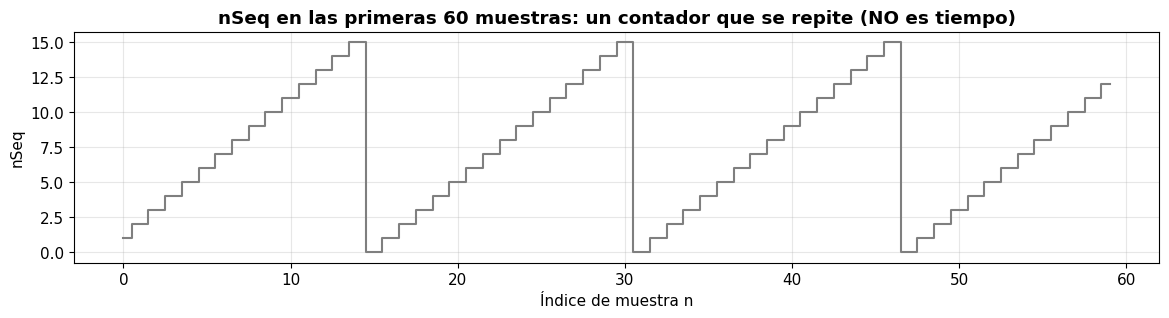

El contador va de 0 a 15.
Muestras con salto distinto de 1 (posibles pérdidas): 0


In [ ]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.step(np.arange(60), datos["nSeq"].values[:60], where="mid", color="tab:gray")
ax.set_title("nSeq en las primeras 60 muestras: un contador que se repite (NO es tiempo)")
ax.set_xlabel("Índice de muestra n"); ax.set_ylabel("nSeq")
plt.show()

# Verificación de paquetes perdidos: el salto esperado entre muestras consecutivas es 1 (módulo del contador)
modulo = int(datos["nSeq"].max()) + 1
saltos = np.diff(datos["nSeq"].values) % modulo
print(f"El contador va de 0 a {modulo-1}.")
print("Muestras con salto distinto de 1 (posibles pérdidas):", int(np.sum(saltos != 1)))

### ❓ Pregunta al estudiante (Bloque 1)
Según la cabecera, ¿cuántos niveles distintos puede tomar el canal `A2`? (Pista: $2^{\text{bits}}$). ¿Por qué es útil verificar `nSeq` antes de analizar la señal?

✍️ **Respuesta:**

---
# 🟦 BLOQUE 2 — Señal ECG original *(15 min)*

## 2.1 Conceptos mínimos

- **Amplitud**: magnitud de la señal (aquí, en mV).
- **Tiempo**: eje horizontal construido con $t = n/F_s$.
- **Frecuencia de muestreo** $F_s$: muestras por segundo (1000 Hz → 1000 muestras/s).
- **Periodo de muestreo** $T_s = 1/F_s$: tiempo entre muestras (1 ms).
- **Morfología ECG**: forma característica de cada latido (onda P, complejo QRS, onda T).
- **Ruido**: componente aleatoria, no deseada, generalmente de banda ancha.
- **Interferencia**: componente no deseada con origen y estructura identificables (p. ej., la red eléctrica a una frecuencia fija).

## 2.2 Extraer `A2` y convertir a milivoltios

El canal `A2` contiene valores del conversor analógico-digital (ADC). Para expresarlos en mV usamos la función de transferencia del sensor ECG de BITalino (hoja de datos del fabricante):

$$ECG_{mV} = \left(\frac{ADC}{2^{n}} - \frac{1}{2}\right)\cdot\frac{V_{CC}}{G_{ECG}}\cdot 1000, \qquad V_{CC}=3.3\,\text{V},\; G_{ECG}=1100$$

> Si tu sensor fuera distinto, puedes trabajar directamente en unidades ADC: los filtros funcionan igual.

In [ ]:
VCC = 3.3       # voltaje de operación (V)
G_ECG = 1100    # ganancia del sensor ECG de BITalino

ecg_adc = datos["A2"].to_numpy(dtype=float)
ecg_mV = ((ecg_adc / 2**resolucion_A2) - 0.5) * VCC / G_ECG * 1000

# Señal de referencia del laboratorio: ECG REAL centrado en cero (restamos la media)
ecg_original = ecg_mV - np.mean(ecg_mV)

# Eje temporal correcto
t = np.arange(len(ecg_original)) / Fs

print(f"Amplitud mínima: {ecg_original.min():.3f} mV | máxima: {ecg_original.max():.3f} mV")
print(f"Desviación estándar: {np.std(ecg_original):.3f} mV")

Amplitud mínima: -0.598 mV | máxima: 0.597 mV
Desviación estándar: 0.115 mV


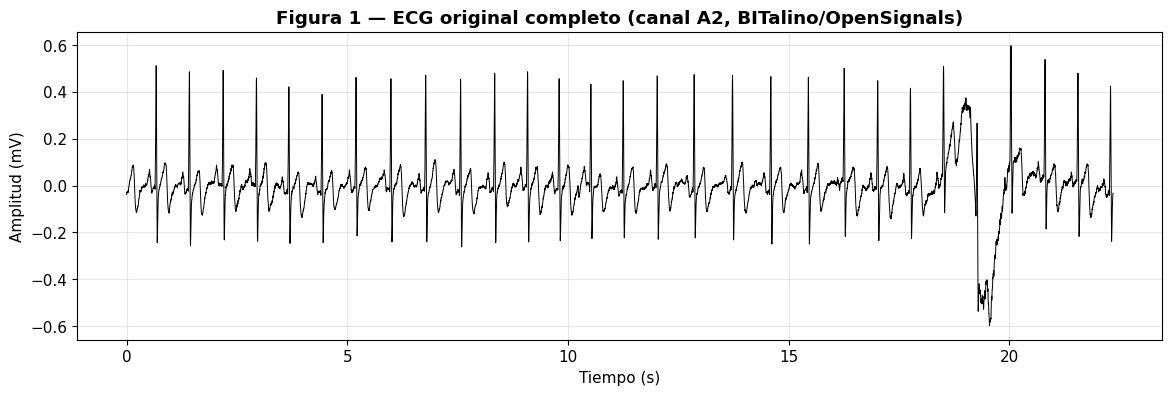

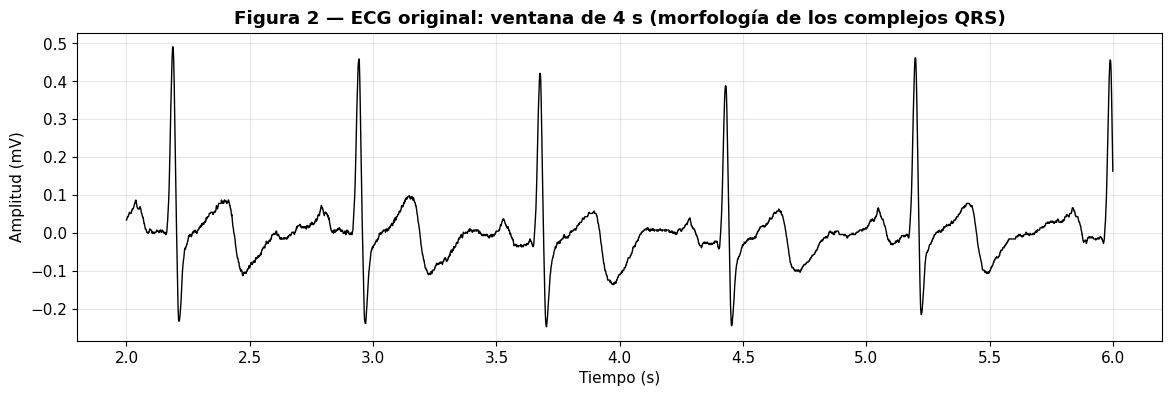

In [ ]:
# Ventana de observación para todos los acercamientos (se ajusta si el registro es corto)
DURACION_ZOOM = 4.0                                    # segundos
T_INICIO_ZOOM = 2.0 if duracion_total > 8 else 0.0     # evitamos el inicio del registro
zoom = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + DURACION_ZOOM)

# Figura 1: ECG completo
plt.figure(figsize=(14, 4))
plt.plot(t, ecg_original, color="black", lw=0.7)
plt.title("Figura 1 — ECG original completo (canal A2, BITalino/OpenSignals)")
plt.xlabel("Tiempo (s)"); plt.ylabel("Amplitud (mV)")
plt.show()

# Figura 2: ventana corta
plt.figure(figsize=(14, 4))
plt.plot(t[zoom], ecg_original[zoom], color="black", lw=1)
plt.title(f"Figura 2 — ECG original: ventana de {DURACION_ZOOM:.0f} s (morfología de los complejos QRS)")
plt.xlabel("Tiempo (s)"); plt.ylabel("Amplitud (mV)")
plt.show()

### 🔎 Interpretación
- En la **Figura 1** se observa la señal completa: verifica si la línea de base es estable o presenta deriva (*baseline wander*), y si hay artefactos.
- En la **Figura 2** identifica los **complejos QRS** (picos agudos), las ondas **P** y **T**.
- Recuerda: aunque esta señal es **real**, ya trae consigo cierta cantidad de ruido propio de la adquisición. No es una señal "perfecta".

### ❓ Pregunta al estudiante (Bloque 2)
A partir de la Figura 2, estima la frecuencia cardiaca (latidos por minuto) contando los complejos QRS en la ventana.

✍️ **Respuesta:**

---
# 🟦 BLOQUE 3 — Contaminación artificial de la señal *(20 min)*

## 3.1 ¿Por qué contaminar artificialmente?

Para **evaluar un filtro necesitamos saber cuál es la "respuesta correcta"**. Si contaminamos nosotros mismos la señal con componentes **conocidas**, podemos comparar la señal filtrada con la original y medir qué tan bien se recuperó.

$$ECG_{contaminado} = ECG_{original} + \text{interferencia}_1 + \text{interferencia}_2 + \text{ruido gaussiano}$$

> ⚠️ **Importante:** esta es una **contaminación artificial y controlada con fines didácticos**. Las frecuencias elegidas **no** representan todas las fuentes reales de ruido de un ECG (en la práctica también hay deriva de línea de base, artefactos de movimiento, ruido muscular/EMG, mal contacto de electrodos, etc.).

**Elección de frecuencias:** en Perú la red eléctrica opera a **60 Hz**, por eso usamos $f_1 = 60$ Hz y su segundo armónico $f_2 = 120$ Hz. Si quieres reproducir el caso europeo, cambia a 50 y 100 Hz. **Todos los parámetros son modificables.**

In [ ]:
# =================== PARÁMETROS MODIFICABLES ===================
f1 = 60        # Hz — interferencia 1 (red eléctrica en Perú)
f2 = 120       # Hz — interferencia 2 (armónico de la red)

escala = np.std(ecg_original)   # referencia de amplitud de la propia señal
amplitud_1 = 1.0 * escala       # amplitud de la interferencia 1 (mV)
amplitud_2 = 0.6 * escala       # amplitud de la interferencia 2 (mV)
sigma_ruido = 0.3 * escala      # desviación estándar del ruido gaussiano (mV)
# ===============================================================

# Fases aleatorias (pero reproducibles): las interferencias reales no empiezan en fase cero
fase_1, fase_2 = rng.uniform(0, 2 * np.pi, size=2)

ruido_senoidal_1 = amplitud_1 * np.sin(2 * np.pi * f1 * t + fase_1)
ruido_senoidal_2 = amplitud_2 * np.sin(2 * np.pi * f2 * t + fase_2)
ruido_gaussiano  = rng.normal(0, sigma_ruido, size=len(t))

ecg_contaminado = (
    ecg_original
    + ruido_senoidal_1
    + ruido_senoidal_2
    + ruido_gaussiano
)

print(f"Interferencia 1: {f1} Hz, amplitud {amplitud_1:.3f} mV")
print(f"Interferencia 2: {f2} Hz, amplitud {amplitud_2:.3f} mV")
print(f"Ruido gaussiano: sigma = {sigma_ruido:.3f} mV")

Interferencia 1: 60 Hz, amplitud 0.115 mV
Interferencia 2: 120 Hz, amplitud 0.069 mV
Ruido gaussiano: sigma = 0.034 mV


## 3.2 Visualización de cada componente

Usamos una ventana de **1 segundo** para que las oscilaciones sean distinguibles.

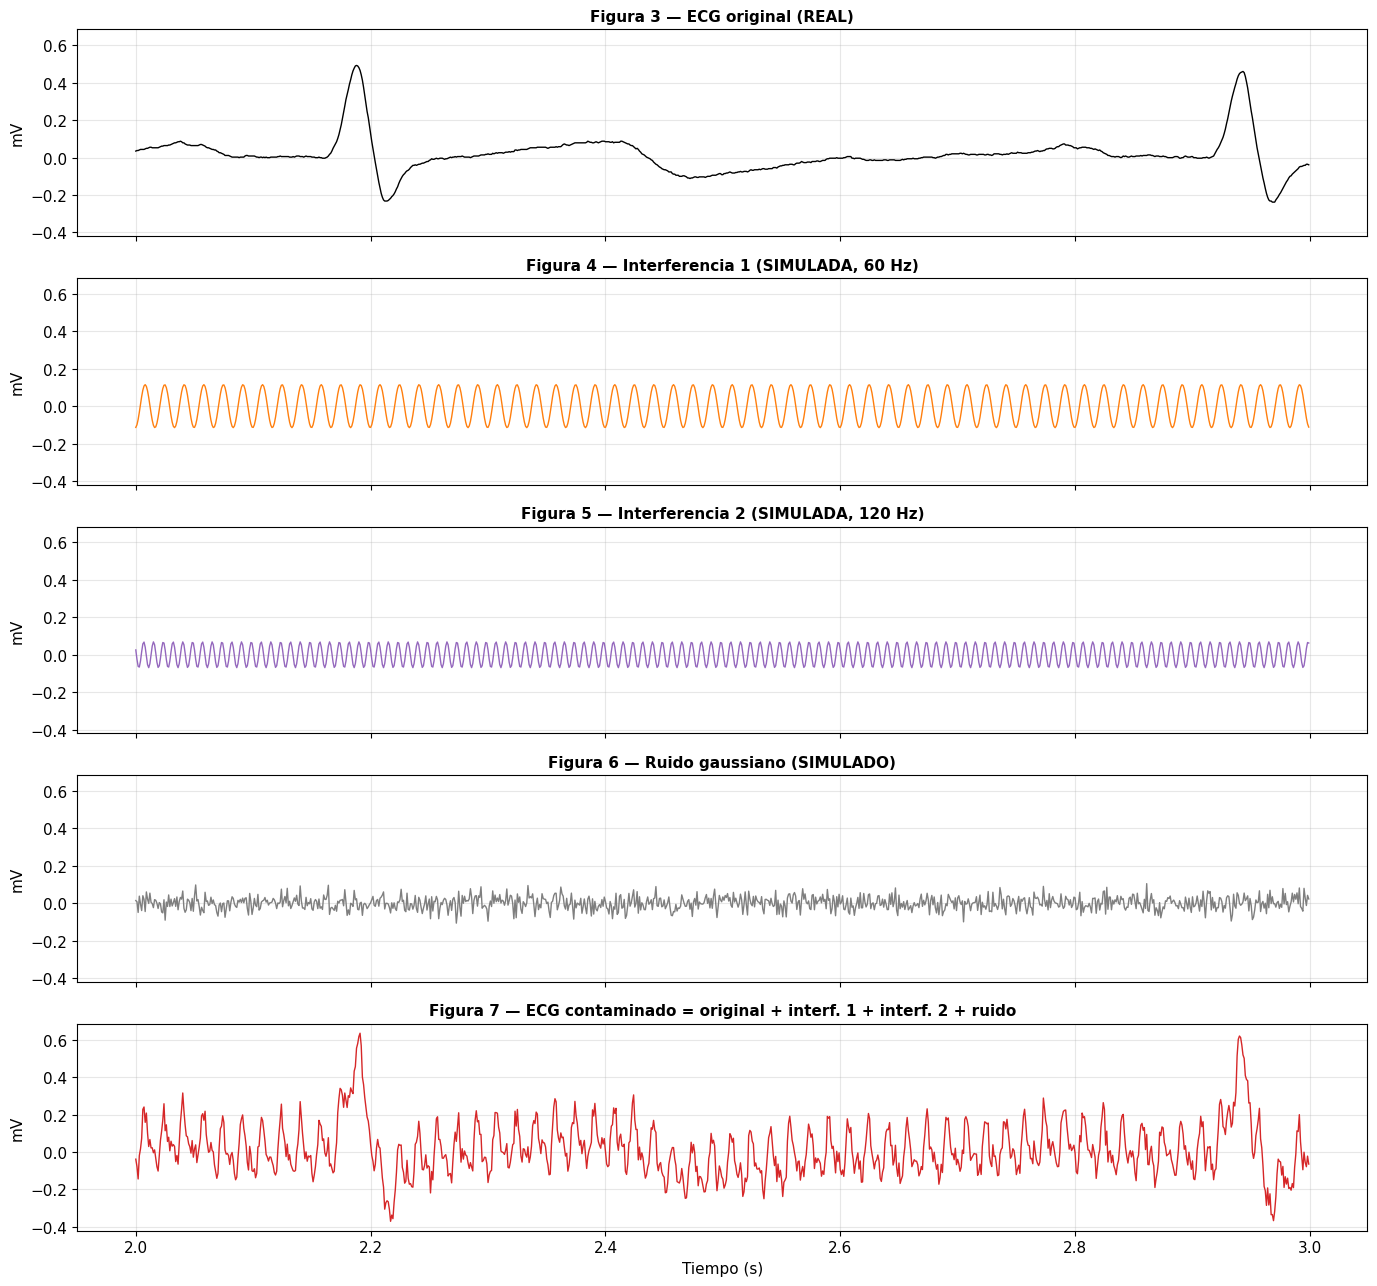

In [ ]:
ventana_1s = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + 1.0)

componentes = [
    ("Figura 3 — ECG original (REAL)", ecg_original, "black"),
    (f"Figura 4 — Interferencia 1 (SIMULADA, {f1} Hz)", ruido_senoidal_1, "tab:orange"),
    (f"Figura 5 — Interferencia 2 (SIMULADA, {f2} Hz)", ruido_senoidal_2, "tab:purple"),
    ("Figura 6 — Ruido gaussiano (SIMULADO)", ruido_gaussiano, "tab:gray"),
    ("Figura 7 — ECG contaminado = original + interf. 1 + interf. 2 + ruido", ecg_contaminado, "tab:red"),
]

fig, ejes = plt.subplots(len(componentes), 1, figsize=(14, 13), sharex=True, sharey=True)
for eje, (titulo, senal, color) in zip(ejes, componentes):
    eje.plot(t[ventana_1s], senal[ventana_1s], color=color, lw=1)
    eje.set_title(titulo, fontsize=11)
    eje.set_ylabel("mV")
ejes[-1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

```text
ECG original
        ↓
+ interferencias (f1, f2)
        ↓
+ ruido gaussiano
        ↓
ECG contaminado
```

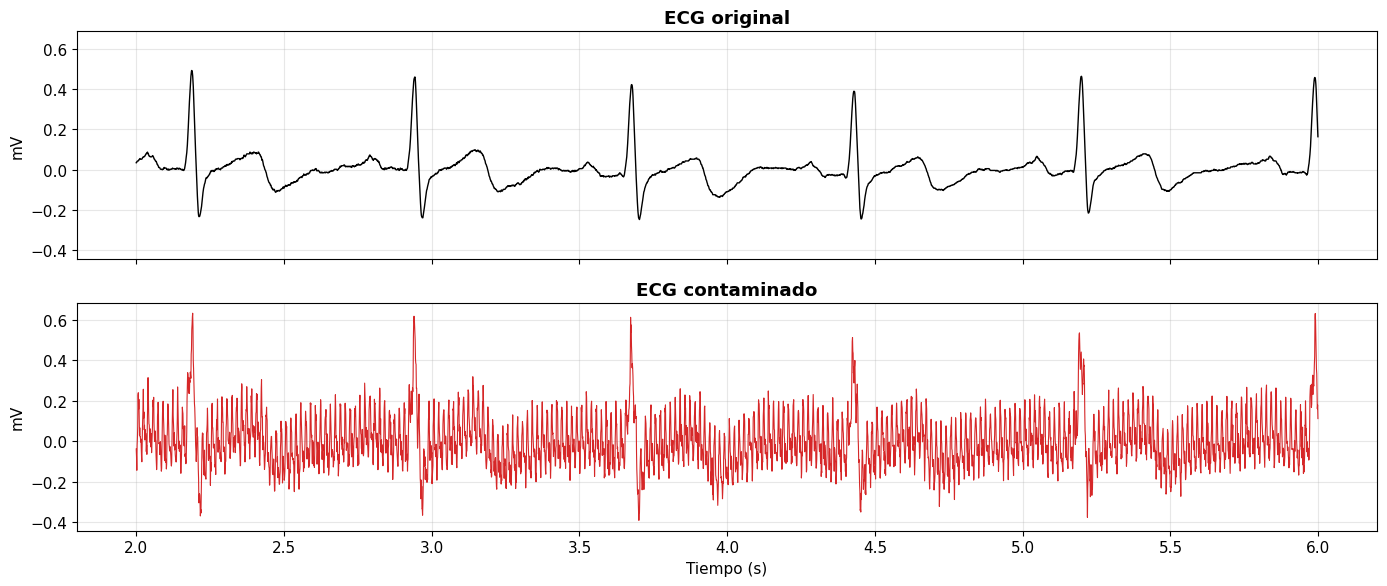

In [ ]:
# Comparación directa en la ventana de 4 s
fig, ejes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
ejes[0].plot(t[zoom], ecg_original[zoom], color="black", lw=1)
ejes[0].set_title("ECG original")
ejes[1].plot(t[zoom], ecg_contaminado[zoom], color="tab:red", lw=0.8)
ejes[1].set_title("ECG contaminado")
for eje in ejes: eje.set_ylabel("mV")
ejes[1].set_xlabel("Tiempo (s)")
plt.tight_layout(); plt.show()

### 🔎 Observa y anota
- ¿Cambió la amplitud aparente de la señal?
- ¿Se conserva la forma de las ondas P y T?
- ¿Qué oscilaciones regulares aparecen?
- ¿Hay ruido de alta frecuencia ("grosor" del trazo)?
- ¿Es más difícil identificar los complejos QRS?

✍️ **Respuesta:**

## 3.3 Análisis en el dominio de la frecuencia

> Una señal puede analizarse no solamente en función del tiempo, sino también en función de sus **componentes frecuenciales**.

```text
Dominio temporal
        ↕   Transformada de Fourier (FFT)
Dominio frecuencial
```

Intuitivamente, la FFT responde: *¿cuánto de cada frecuencia contiene la señal?* Una senoide pura de frecuencia $f_0$ aparece como **un pico estrecho** en $f_0$. El ruido gaussiano, en cambio, reparte su energía en **todas** las frecuencias (fondo plano).

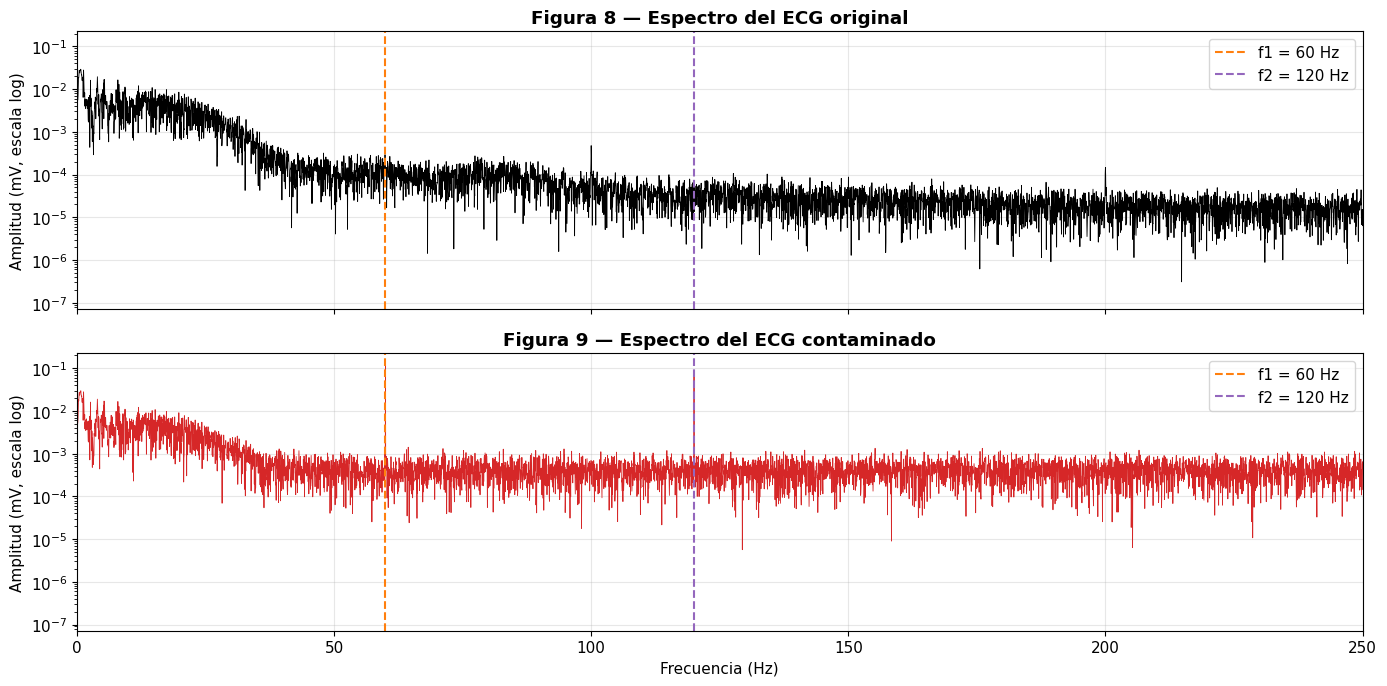

In [ ]:
def espectro_amplitud(x, Fs):
    """Espectro de amplitud de un solo lado usando la FFT de NumPy."""
    N = len(x)
    X = np.fft.rfft(x - np.mean(x))
    frecuencias = np.fft.rfftfreq(N, d=1/Fs)
    amplitud = 2 * np.abs(X) / N
    return frecuencias[1:], amplitud[1:]   # omitimos 0 Hz (la media ya fue restada)

freq, amp_original = espectro_amplitud(ecg_original, Fs)
_,    amp_contaminado = espectro_amplitud(ecg_contaminado, Fs)

F_MAX_GRAFICO = min(250, Fs / 2)
fig, ejes = plt.subplots(2, 1, figsize=(14, 7), sharex=True, sharey=True)
ejes[0].semilogy(freq, amp_original, color="black", lw=0.6)
ejes[0].set_title("Figura 8 — Espectro del ECG original")
ejes[1].semilogy(freq, amp_contaminado, color="tab:red", lw=0.6)
ejes[1].set_title("Figura 9 — Espectro del ECG contaminado")
for eje in ejes:
    eje.axvline(f1, color="tab:orange", ls="--", label=f"f1 = {f1} Hz")
    eje.axvline(f2, color="tab:purple", ls="--", label=f"f2 = {f2} Hz")
    eje.set_ylabel("Amplitud (mV, escala log)")
    eje.legend(loc="upper right")
ejes[1].set_xlabel("Frecuencia (Hz)")
ejes[1].set_xlim(0, F_MAX_GRAFICO)
plt.tight_layout(); plt.show()

### 🔎 Interpretación
- El ECG concentra la mayor parte de su energía en **bajas frecuencias** (aprox. < 40 Hz).
- En el espectro contaminado aparecen **dos picos nítidos** exactamente en $f_1$ y $f_2$: son las interferencias que **nosotros** introdujimos.
- El ruido gaussiano **eleva el "piso"** del espectro en todas las frecuencias.
- Si en el ECG original ya aparece algún pico en 60 Hz, ¡esa sería interferencia **real** de la adquisición!

### ❓ Pregunta al estudiante
¿Por qué la interferencia aparece como un pico y el ruido gaussiano como un fondo? ¿Cuál de los dos será más fácil de eliminar con un filtro?

✍️ **Respuesta:**

---
# 🟦 BLOQUE 4 — Aplicación de filtros digitales *(25 min)*

## 4.1 Tipos de filtros

| Filtro | Deja pasar | Uso típico en ECG |
|---|---|---|
| **Pasa-bajas** | Frecuencias por debajo de $f_c$ | Atenuar ruido de alta frecuencia (EMG, ruido electrónico). |
| **Pasa-altas** | Frecuencias por encima de $f_c$ | Eliminar la deriva de línea de base (respiración, movimiento). |
| **Pasa-banda** | Frecuencias entre $f_{c1}$ y $f_{c2}$ | Combinar ambos: típico 0.5 – 40 Hz para monitoreo. |
| **Notch (rechaza-banda)** | Todo excepto una banda muy estrecha | Eliminar una interferencia de frecuencia conocida (red eléctrica). |

**Herramientas de `scipy.signal`:**
- `butter`: diseña un filtro Butterworth (respuesta plana en la banda de paso).
- `iirnotch`: diseña un filtro notch centrado en una frecuencia.
- `filtfilt`: aplica el filtro hacia adelante y hacia atrás → **fase cero** (no desplaza los QRS en el tiempo).
- `freqz`: calcula la respuesta en frecuencia del filtro.

> 💡 Para el pasa-banda usamos la forma **SOS** (*second-order sections*) con `sosfiltfilt`, que es el equivalente numéricamente estable de `filtfilt` cuando la frecuencia de corte es muy baja respecto a $F_s$ (0.5 Hz frente a 1000 Hz).

In [ ]:
def respuesta_sos(sos, Fs, n_puntos=16384):
    """Respuesta en frecuencia de un filtro en formato SOS (compatible con varias versiones de SciPy)."""
    funcion = getattr(signal, "freqz_sos", None) or signal.sosfreqz
    return funcion(sos, worN=n_puntos, fs=Fs)

def graficar_respuesta(w, h, titulo, marcas=()):
    plt.figure(figsize=(14, 3.5))
    plt.plot(w, 20 * np.log10(np.maximum(np.abs(h), 1e-10)), color="tab:blue")
    for f in marcas:
        plt.axvline(f, color="tab:red", ls="--", lw=1)
    plt.ylim(-80, 5); plt.xlim(0, F_MAX_GRAFICO)
    plt.title(titulo); plt.xlabel("Frecuencia (Hz)"); plt.ylabel("Ganancia (dB)")
    plt.show()

## 4.2 Experimento A — Filtro pasa-banda (Butterworth 0.5 – 40 Hz)

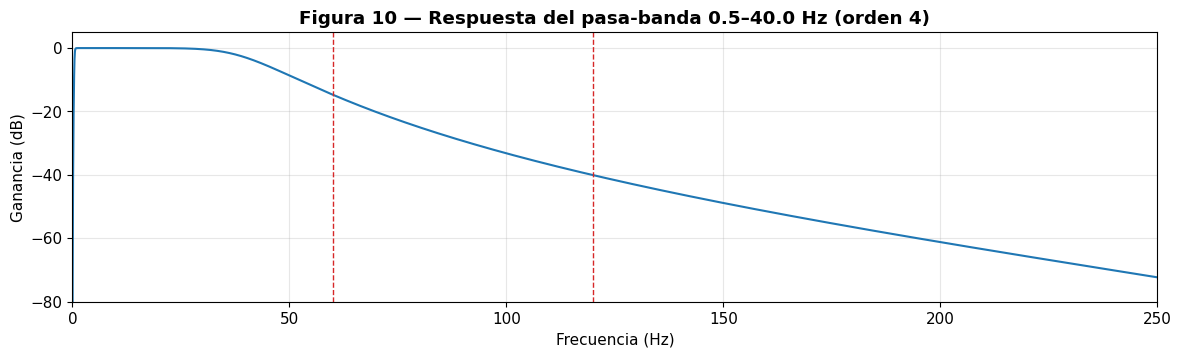

In [ ]:
# =================== PARÁMETROS MODIFICABLES ===================
fc_baja = 0.5     # Hz
fc_alta = 40.0    # Hz
orden_pb = 4
# ===============================================================

sos_pasabanda = signal.butter(orden_pb, [fc_baja, fc_alta], btype="bandpass", fs=Fs, output="sos")
ecg_pasabanda = signal.sosfiltfilt(sos_pasabanda, ecg_contaminado)

w, h = respuesta_sos(sos_pasabanda, Fs)
graficar_respuesta(w, h, f"Figura 10 — Respuesta del pasa-banda {fc_baja}–{fc_alta} Hz (orden {orden_pb})", marcas=(f1, f2))

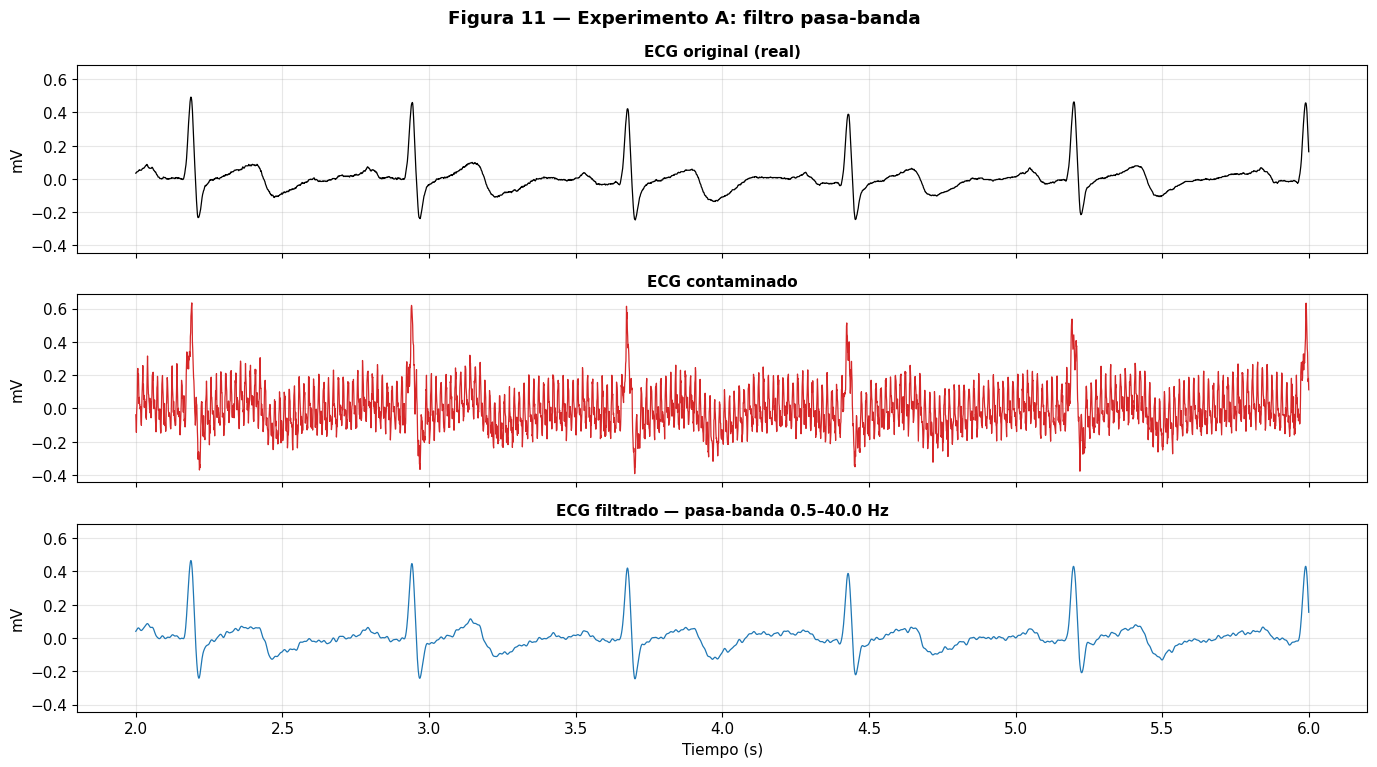

In [ ]:
def comparar_senales(lista, titulo_general, mascara=zoom):
    """Grafica varias señales (titulo, señal, color) apiladas en la misma ventana temporal."""
    fig, ejes = plt.subplots(len(lista), 1, figsize=(14, 2.6 * len(lista)), sharex=True, sharey=True)
    for eje, (titulo, senal, color) in zip(ejes, lista):
        eje.plot(t[mascara], senal[mascara], color=color, lw=0.9)
        eje.set_title(titulo, fontsize=11); eje.set_ylabel("mV")
    ejes[-1].set_xlabel("Tiempo (s)")
    fig.suptitle(titulo_general, fontweight="bold")
    plt.tight_layout(); plt.show()

comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado — pasa-banda {fc_baja}–{fc_alta} Hz", ecg_pasabanda, "tab:blue"),
], "Figura 11 — Experimento A: filtro pasa-banda")

### 🔎 Interpretación — Experimento A
- **¿Qué se eliminó?** Ambas interferencias ($f_1$ y $f_2$ están fuera de la banda de paso) y la mayor parte del ruido gaussiano de alta frecuencia.
- **¿Qué permanece?** El ruido gaussiano que cae **dentro** de 0.5 – 40 Hz: ningún filtro lineal puede separarlo del ECG porque comparten frecuencias.
- **¿Qué se pudo afectar?** El pasa-banda también elimina contenido **real** del ECG: la deriva de línea de base (< 0.5 Hz) y parte del contenido de alta frecuencia del QRS (> 40 Hz). Observa si los picos R se ven un poco más bajos o redondeados.

## 4.3 Experimento B — Filtro notch

El notch elimina **una frecuencia concreta** y deja prácticamente intacto el resto del espectro. El **factor de calidad** $Q$ controla el ancho de la muesca: $\text{ancho} \approx f_0 / Q$.

**B1:** notch solo en $f_1$. **B2:** dos notch en cascada ($f_1$ y $f_2$).

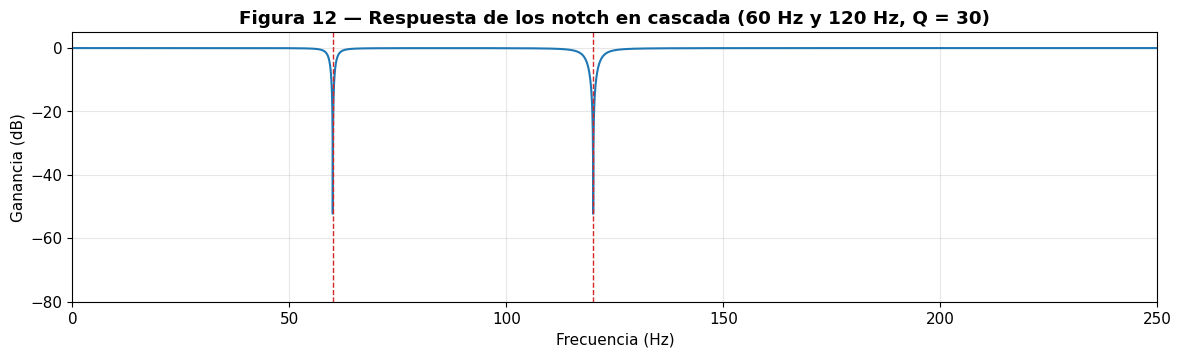

In [ ]:
Q = 30   # factor de calidad (mayor Q → muesca más estrecha)

b_notch1, a_notch1 = signal.iirnotch(f1, Q, fs=Fs)
b_notch2, a_notch2 = signal.iirnotch(f2, Q, fs=Fs)

# B1: solo f1
ecg_notch_f1 = signal.filtfilt(b_notch1, a_notch1, ecg_contaminado)
# B2: f1 y luego f2 (cascada)
ecg_notch_f1f2 = signal.filtfilt(b_notch2, a_notch2, ecg_notch_f1)

# Respuesta en frecuencia de la cascada (producto de ambas respuestas)
w, h1 = signal.freqz(b_notch1, a_notch1, worN=16384, fs=Fs)
_, h2 = signal.freqz(b_notch2, a_notch2, worN=16384, fs=Fs)
graficar_respuesta(w, h1 * h2, f"Figura 12 — Respuesta de los notch en cascada ({f1} Hz y {f2} Hz, Q = {Q})", marcas=(f1, f2))

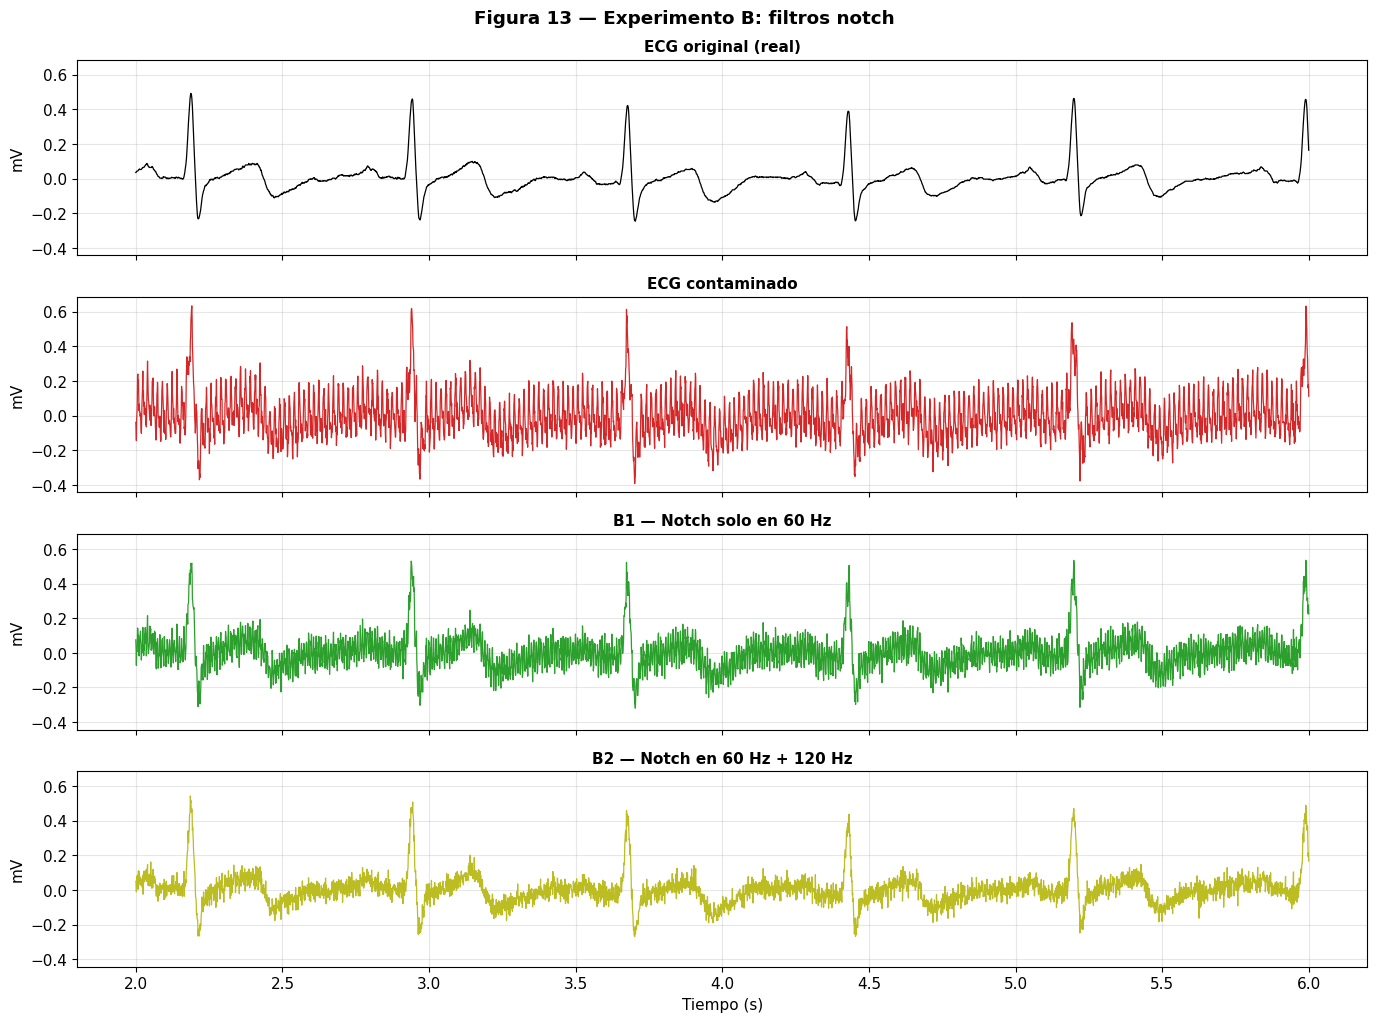

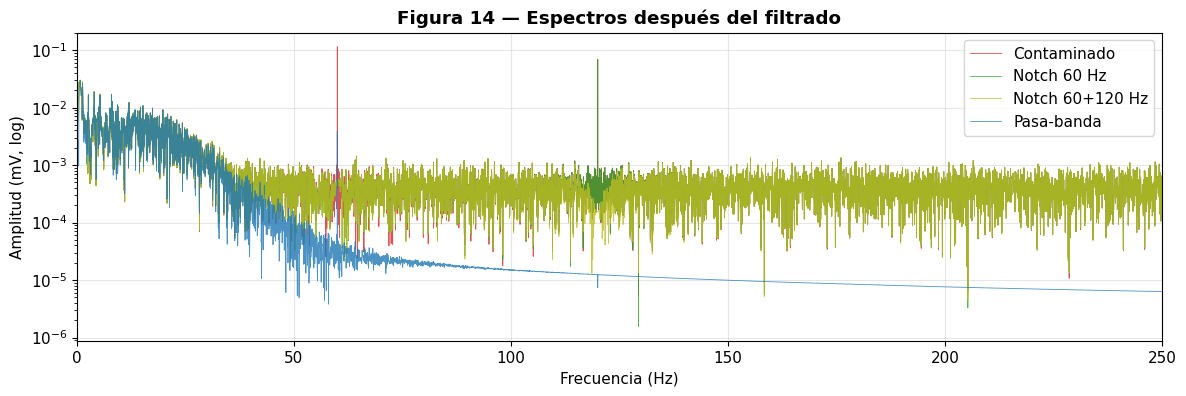

In [ ]:
comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"B1 — Notch solo en {f1} Hz", ecg_notch_f1, "tab:green"),
    (f"B2 — Notch en {f1} Hz + {f2} Hz", ecg_notch_f1f2, "tab:olive"),
], "Figura 13 — Experimento B: filtros notch")

# Espectros después de cada filtrado
fig, eje = plt.subplots(figsize=(14, 4))
for etiqueta, senal, color in [("Contaminado", ecg_contaminado, "tab:red"),
                               (f"Notch {f1} Hz", ecg_notch_f1, "tab:green"),
                               (f"Notch {f1}+{f2} Hz", ecg_notch_f1f2, "tab:olive"),
                               ("Pasa-banda", ecg_pasabanda, "tab:blue")]:
    fr, am = espectro_amplitud(senal, Fs)
    eje.semilogy(fr, am, lw=0.6, label=etiqueta, color=color, alpha=0.8)
eje.set_xlim(0, F_MAX_GRAFICO); eje.legend()
eje.set_title("Figura 14 — Espectros después del filtrado")
eje.set_xlabel("Frecuencia (Hz)"); eje.set_ylabel("Amplitud (mV, log)")
plt.show()

### 🔎 Interpretación — Experimento B
- **B1** elimina el pico en $f_1$, pero el de $f_2$ **sigue ahí**: el notch solo actúa donde se lo indicamos.
- **B2** elimina ambos picos, pero el **ruido gaussiano permanece** (el notch no reduce el ruido de banda ancha).
- **Ventaja:** el notch altera muy poco la morfología del ECG porque solo "corta" una banda estrecha.
- **Limitación:** exige conocer la frecuencia exacta y que esta **no cambie** en el tiempo.

### ❓ Pregunta al estudiante
Cambia `Q` a 5 y luego a 100. ¿Qué ocurre con el ancho de la muesca (Figura 12) y con la señal filtrada?

✍️ **Respuesta:**

## 4.4 Comparación cuantitativa

Las métricas **complementan** (no reemplazan) la evaluación visual:

| Métrica | Fórmula | Interpretación |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{N}\sum (x - \hat{x})^2}$ | Error promedio (mV). **Menor es mejor.** |
| **SNR** | $10\log_{10}\frac{\sum x^2}{\sum (x-\hat{x})^2}$ | Relación señal/error en dB. **Mayor es mejor.** |
| **Correlación** $r$ | coeficiente de Pearson | Similitud de forma (1 = idéntica). |

donde $x$ es el ECG original y $\hat{x}$ la señal evaluada. Excluimos los primeros y últimos 2 s para evitar efectos de borde (y el tiempo de convergencia del filtro adaptativo que veremos luego).

In [ ]:
MARGEN_S = 2.0
evaluacion = (t >= MARGEN_S) & (t <= t[-1] - MARGEN_S)

def calcular_metricas(referencia, estimada, mascara=evaluacion):
    x, y = referencia[mascara], estimada[mascara]
    error = y - x
    rmse = np.sqrt(np.mean(error ** 2))
    snr = 10 * np.log10(np.sum(x ** 2) / np.sum(error ** 2))
    r = np.corrcoef(x, y)[0, 1]
    return {"RMSE (mV)": rmse, "SNR (dB)": snr, "Correlación r": r}

resultados = {
    "Contaminado (sin filtrar)": calcular_metricas(ecg_original, ecg_contaminado),
    "A — Pasa-banda": calcular_metricas(ecg_original, ecg_pasabanda),
    f"B1 — Notch {f1} Hz": calcular_metricas(ecg_original, ecg_notch_f1),
    f"B2 — Notch {f1}+{f2} Hz": calcular_metricas(ecg_original, ecg_notch_f1f2),
}
pd.DataFrame(resultados).T.round(4)

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.1004,1.5343,0.7656
A — Pasa-banda,0.0344,10.8465,0.9591
B1 — Notch 60 Hz,0.0595,6.0810,0.8952
B2 — Notch 60+120 Hz,0.0341,10.8992,0.9615


### ¿Cuánto modifica el filtro a la propia señal original?

Un detalle importante: el pasa-banda **también** cambia el ECG original (quita su deriva de base y su contenido > 40 Hz). Para separar "ruido no eliminado" de "distorsión del filtro", filtramos el **original limpio** y lo comparamos consigo mismo.

In [ ]:
ecg_original_pasabanda = signal.sosfiltfilt(sos_pasabanda, ecg_original)
ecg_original_notch = signal.filtfilt(b_notch2, a_notch2, signal.filtfilt(b_notch1, a_notch1, ecg_original))

pd.DataFrame({
    "Pasa-banda aplicado al ORIGINAL": calcular_metricas(ecg_original, ecg_original_pasabanda),
    "Notch f1+f2 aplicado al ORIGINAL": calcular_metricas(ecg_original, ecg_original_notch),
}).T.round(4)

,RMSE (mV),SNR (dB),Correlación r
Pasa-banda aplicado al ORIGINAL,0.0326,11.2978,0.9636
Notch f1+f2 aplicado al ORIGINAL,0.0006,45.5851,1.0000


### 🔎 Interpretación
- Si el pasa-banda aplicado al original **ya** produce un error apreciable, parte del "error" del Experimento A **no es ruido residual**, sino **distorsión introducida por el filtro** (pérdida de deriva de base y de componentes rápidas del QRS).
- El notch casi no modifica el original → distorsión mínima, pero tampoco reduce el ruido gaussiano.
- Conclusión: **ninguna métrica aislada cuenta toda la historia**.

### ❓ Pregunta al estudiante
¿Qué filtro obtuvo mejor SNR? ¿Coincide con lo que observaste visualmente? Explica cualquier diferencia.

✍️ **Respuesta:**

---
# 🟦 BLOQUE 5 — Filtros adaptativos y Transformada Wavelet *(20 min)*

## 5.1 ¿Qué es un filtro adaptativo?

Un filtro **convencional** tiene coeficientes **fijos**: se diseña una vez y se aplica igual a toda la señal. Un filtro **adaptativo** **modifica sus coeficientes muestra a muestra** en función de la información que recibe, por lo que puede seguir interferencias cuya amplitud o fase cambian en el tiempo.

```text
Señal contaminada d[n] ──────────────────────────►(+)──► e[n] = ECG estimado
                                                    ▲(−)
                                                    │
señal de referencia x[n] ──► Filtro adaptativo ──► y[n] = interferencia estimada
                                  ▲
                                  └──── se ajusta usando el error e[n]
```

| Concepto | Significado en este laboratorio |
|---|---|
| **Señal de referencia** $x[n]$ | Señal **correlacionada con la interferencia** pero no con el ECG (aquí: senos y cosenos de $f_1$ y $f_2$). En la práctica puede provenir de un sensor que capta la red eléctrica. |
| **Coeficientes** $w$ | Pesos que el filtro ajusta para "imitar" la interferencia. |
| **Salida** $y[n] = w^T x[n]$ | Estimación de la interferencia. |
| **Error** $e[n] = d[n] - y[n]$ | Lo que queda al restar la interferencia estimada: **es nuestro ECG limpio**. |
| **Adaptación (LMS)** | $w[n+1] = w[n] + 2\mu\, e[n]\, x[n]$ |
| **Paso** $\mu$ | Velocidad de aprendizaje: grande → rápido pero inestable/distorsionante; pequeño → lento pero preciso. |

El algoritmo **LMS** (*Least Mean Squares*) minimiza poco a poco la potencia del error. Como el ECG no está correlacionado con la referencia, la única forma de reducir el error es **cancelar la interferencia**.

In [ ]:
def filtro_lms(senal_contaminada, referencias, mu):
    """
    Cancelador adaptativo de interferencias con algoritmo LMS (versión didáctica).
    senal_contaminada : vector d[n] de tamaño N
    referencias       : matriz N x M (cada columna es una señal de referencia)
    mu                : paso de adaptación
    Devuelve: e (señal limpia estimada), y (interferencia estimada), historial de pesos
    """
    N, M = referencias.shape
    w = np.zeros(M)                       # los coeficientes empiezan en cero: el filtro "no sabe nada"
    y = np.zeros(N)
    e = np.zeros(N)
    historial_w = np.zeros((N, M))
    for n in range(N):
        x_n = referencias[n]              # vector de referencia en el instante n
        y[n] = w @ x_n                    # 1) estimar la interferencia
        e[n] = senal_contaminada[n] - y[n]  # 2) calcular el error (ECG estimado)
        w = w + 2 * mu * e[n] * x_n       # 3) actualizar los coeficientes (LMS)
        historial_w[n] = w
    return e, y, historial_w

# Referencias: seno y coseno de cada frecuencia (permiten ajustar amplitud Y fase)
referencias = np.column_stack([
    np.sin(2 * np.pi * f1 * t), np.cos(2 * np.pi * f1 * t),
    np.sin(2 * np.pi * f2 * t), np.cos(2 * np.pi * f2 * t),
])

MU = 0.005   # =================== PARÁMETRO MODIFICABLE ===================
ecg_lms, interferencia_estimada, pesos = filtro_lms(ecg_contaminado, referencias, MU)
print("Filtrado adaptativo completado.")

Filtrado adaptativo completado.


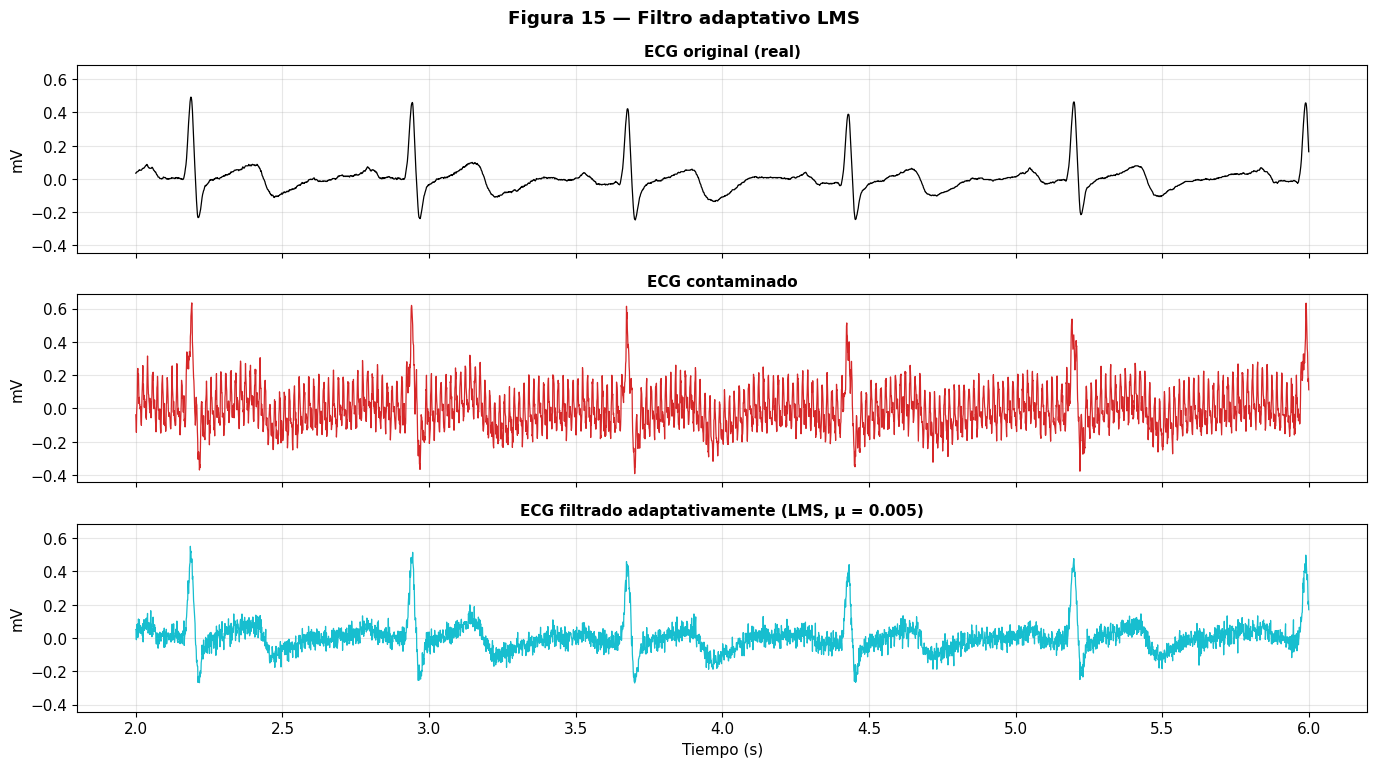

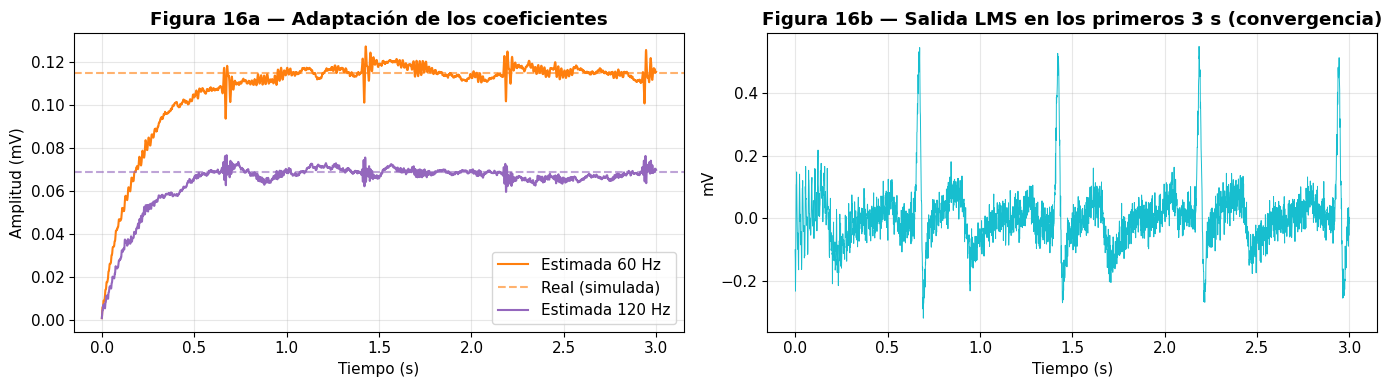

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.1004,1.5343,0.7656
A — Pasa-banda,0.0344,10.8465,0.9591
B1 — Notch 60 Hz,0.0595,6.0810,0.8952
B2 — Notch 60+120 Hz,0.0341,10.8992,0.9615
LMS adaptativo,0.0348,10.7294,0.9608


In [ ]:
comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado adaptativamente (LMS, μ = {MU})", ecg_lms, "tab:cyan"),
], "Figura 15 — Filtro adaptativo LMS")

# ¿Cómo "aprende" el filtro? Amplitud estimada de cada interferencia en el tiempo
amplitud_est_1 = np.hypot(pesos[:, 0], pesos[:, 1])
amplitud_est_2 = np.hypot(pesos[:, 2], pesos[:, 3])
primeros = t < 3.0

fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
ejes[0].plot(t[primeros], amplitud_est_1[primeros], label=f"Estimada {f1} Hz", color="tab:orange")
ejes[0].axhline(amplitud_1, ls="--", color="tab:orange", alpha=0.6, label="Real (simulada)")
ejes[0].plot(t[primeros], amplitud_est_2[primeros], label=f"Estimada {f2} Hz", color="tab:purple")
ejes[0].axhline(amplitud_2, ls="--", color="tab:purple", alpha=0.6)
ejes[0].set_title("Figura 16a — Adaptación de los coeficientes")
ejes[0].set_xlabel("Tiempo (s)"); ejes[0].set_ylabel("Amplitud (mV)"); ejes[0].legend()

ejes[1].plot(t[primeros], ecg_lms[primeros], color="tab:cyan", lw=0.7)
ejes[1].set_title("Figura 16b — Salida LMS en los primeros 3 s (convergencia)")
ejes[1].set_xlabel("Tiempo (s)"); ejes[1].set_ylabel("mV")
plt.tight_layout(); plt.show()

resultados["LMS adaptativo"] = calcular_metricas(ecg_original, ecg_lms)
pd.DataFrame(resultados).T.round(4)

### 🔎 Interpretación — Filtro adaptativo
- Al inicio los coeficientes valen cero: la salida **todavía contiene la interferencia**. En unos cientos de milisegundos los coeficientes **convergen** a la amplitud real de cada interferencia (Figura 16a).
- Una vez adaptado, el LMS cancela $f_1$ y $f_2$ con muy poca alteración del ECG.
- **El ruido gaussiano permanece**: no está correlacionado con la referencia, así que el filtro no puede "aprenderlo".
- Su gran ventaja frente al notch aparece cuando la interferencia **cambia** (amplitud/fase variables): el LMS la sigue; el notch fijo no se entera.

### ❓ Pregunta al estudiante
Cambia `MU` a 0.0005 y a 0.05. ¿Qué pasa con la velocidad de convergencia (Figura 16a) y con la calidad de la señal?

✍️ **Respuesta:**

## 5.2 Transformada Wavelet

> ### ¿Para qué sirve la Transformada Wavelet en el procesamiento de señales biomédicas?

La FFT nos dice **qué frecuencias** hay en la señal, pero **no cuándo** aparecen (analiza la señal completa de forma global). La **Transformada Wavelet** descompone la señal usando pequeñas "ondas" (*wavelets*) de duración limitada, a distintas **escalas**:

- **Escalas pequeñas** → detalles rápidos (alta frecuencia), bien localizados en el tiempo.
- **Escalas grandes** → tendencias lentas (baja frecuencia).

Esto encaja muy bien con el ECG:
- el **complejo QRS** es un evento rápido y localizado;
- las ondas **P** y **T** son más lentas;
- el **ruido** suele dispersarse en los detalles finos con coeficientes pequeños;
- la **deriva de base** vive en la aproximación más gruesa.

### Descomposición Wavelet Discreta (DWT)

En cada nivel la señal se divide en una **aproximación** (A, parte lenta) y un **detalle** (D, parte rápida); la aproximación se vuelve a dividir:

```text
Señal ─┬─► D1 (Fs/4 – Fs/2)
       └─► A1 ─┬─► D2 (Fs/8 – Fs/4)
               └─► A2 ─┬─► D3 ...
                       └─► ... ─► A_L (la parte más lenta)
```

Usaremos la wavelet **Daubechies 4 (`db4`)**, muy empleada en ECG porque su forma se parece a la de un complejo QRS.

In [ ]:
WAVELET = "db4"
nivel_max = pywt.dwt_max_level(len(ecg_original), pywt.Wavelet(WAVELET).dec_len)
NIVEL = min(8, nivel_max)

# Banda de frecuencias aproximada de cada nivel
print(f"Wavelet: {WAVELET} | Niveles: {NIVEL}\n")
print(f"A{NIVEL}: 0 – {Fs / 2**(NIVEL+1):.1f} Hz (aproximación)")
for j in range(NIVEL, 0, -1):
    print(f"D{j}: {Fs / 2**(j+1):.1f} – {Fs / 2**j:.1f} Hz")
print(f"\nInterferencia 1 ({f1} Hz) y 2 ({f2} Hz): ubícalas en la tabla anterior.")

def componentes_por_nivel(x, wavelet, nivel):
    """Reconstruye por separado la contribución de la aproximación y de cada detalle (en el dominio del tiempo)."""
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    componentes = {}
    nombres = [f"A{nivel}"] + [f"D{j}" for j in range(nivel, 0, -1)]
    for i, nombre in enumerate(nombres):
        coefs_solo = [c if k == i else np.zeros_like(c) for k, c in enumerate(coefs)]
        componentes[nombre] = pywt.waverec(coefs_solo, wavelet)[:len(x)]
    return componentes

comp_original = componentes_por_nivel(ecg_original, WAVELET, NIVEL)
comp_contaminado = componentes_por_nivel(ecg_contaminado, WAVELET, NIVEL)

Wavelet: db4 | Niveles: 8

A8: 0 – 2.0 Hz (aproximación)
D8: 2.0 – 3.9 Hz
D7: 3.9 – 7.8 Hz
D6: 7.8 – 15.6 Hz
D5: 15.6 – 31.2 Hz
D4: 31.2 – 62.5 Hz
D3: 62.5 – 125.0 Hz
D2: 125.0 – 250.0 Hz
D1: 250.0 – 500.0 Hz

Interferencia 1 (60 Hz) y 2 (120 Hz): ubícalas en la tabla anterior.


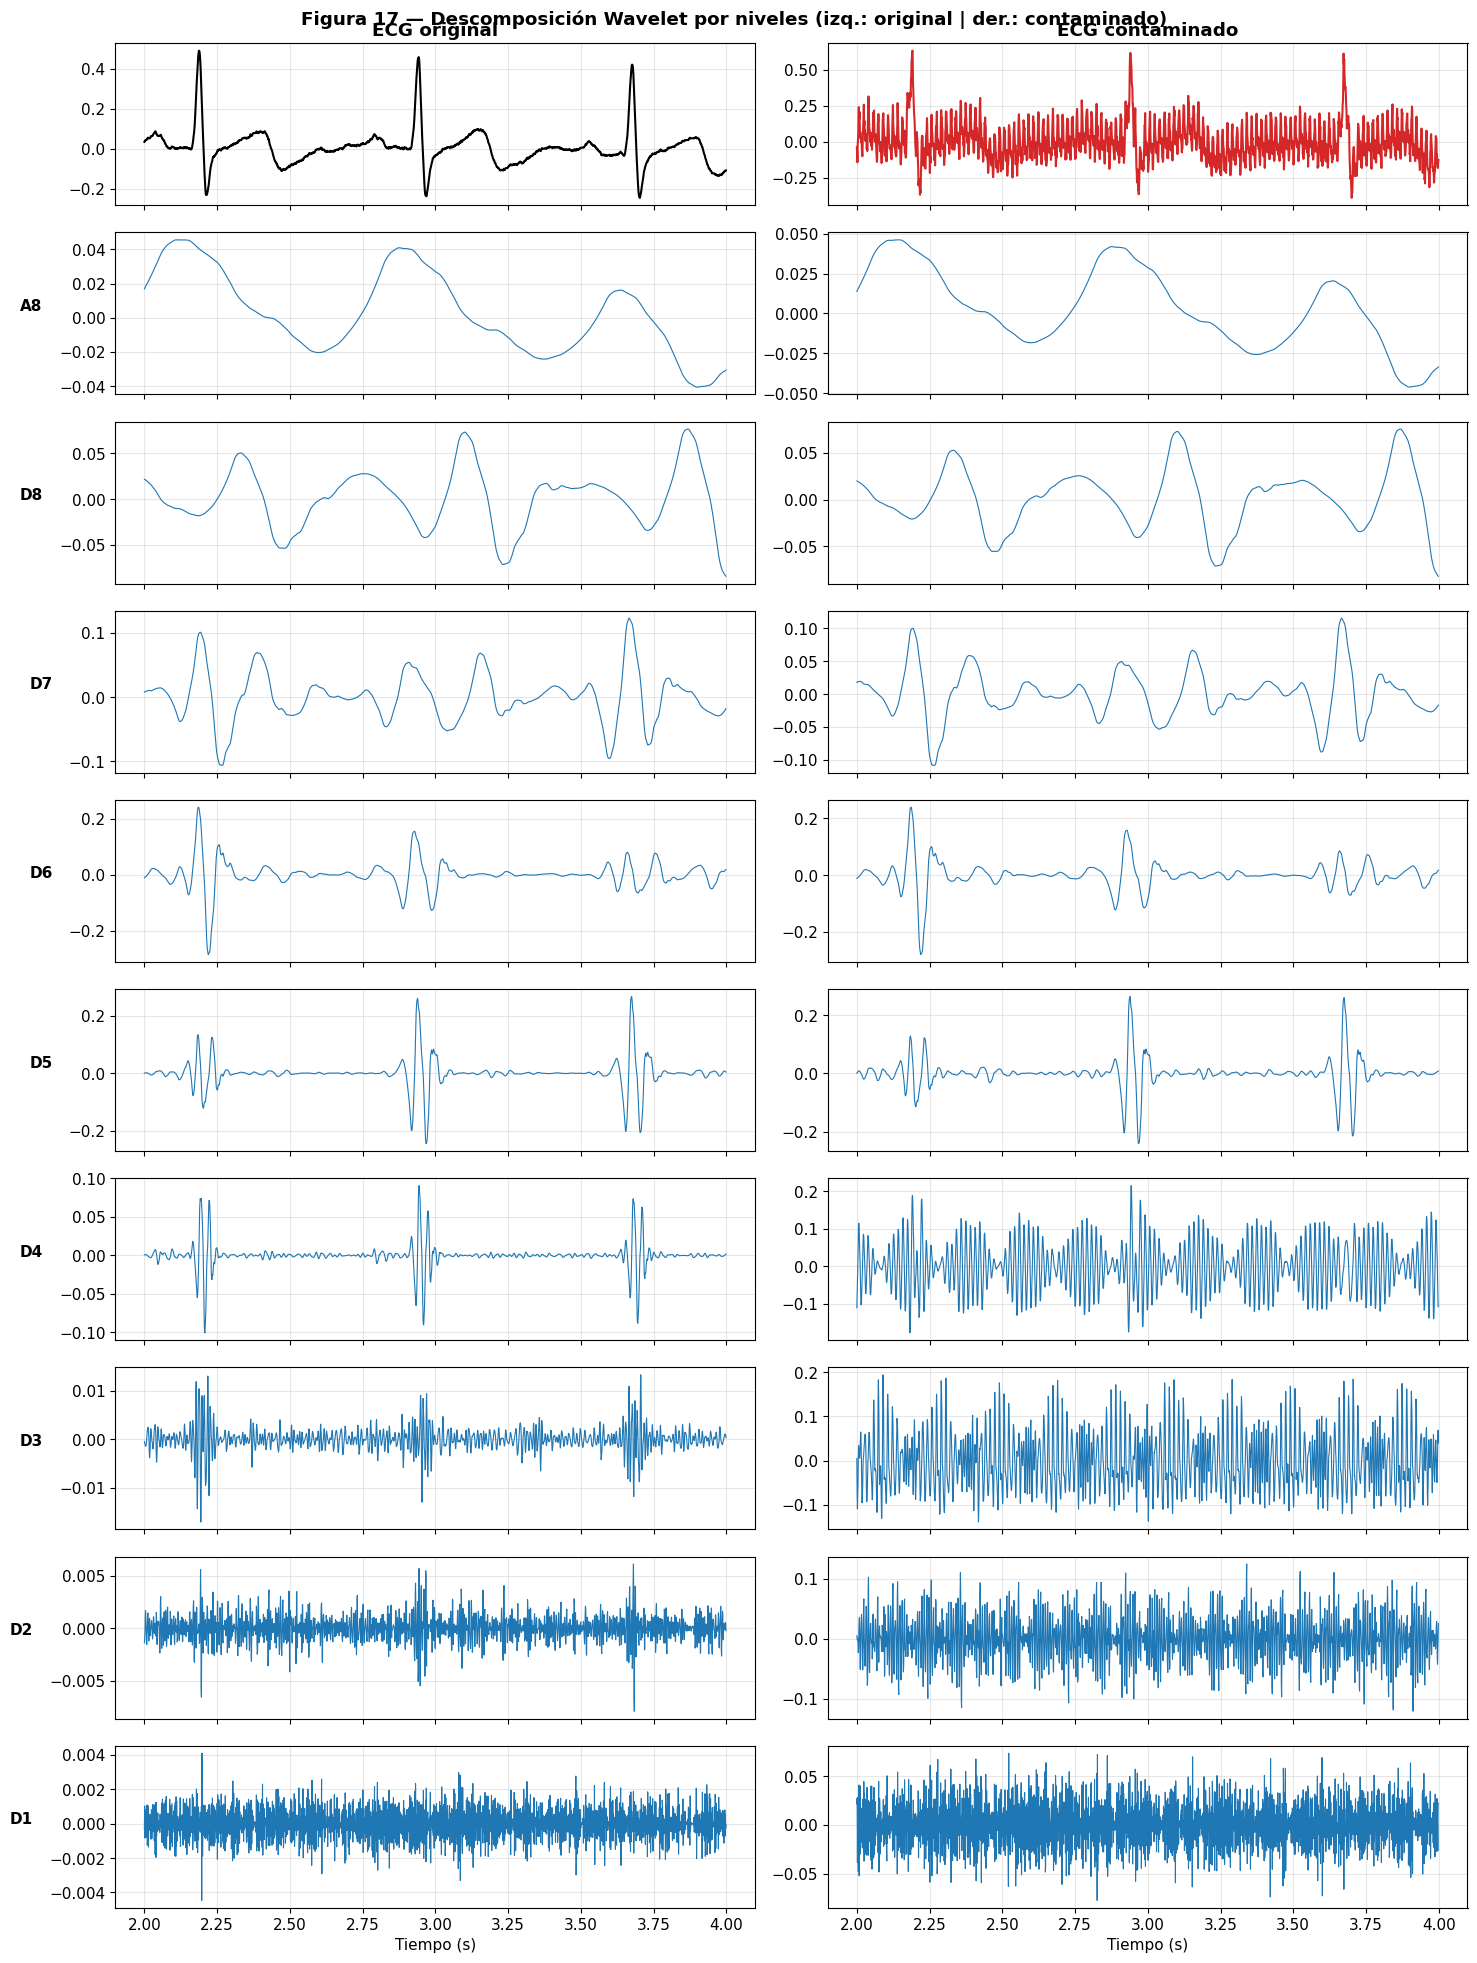

In [ ]:
ventana_2s = (t >= T_INICIO_ZOOM) & (t < T_INICIO_ZOOM + 2.0)
nombres = list(comp_original.keys())

fig, ejes = plt.subplots(len(nombres) + 1, 2, figsize=(15, 2 * (len(nombres) + 1)), sharex=True)
ejes[0, 0].plot(t[ventana_2s], ecg_original[ventana_2s], color="black"); ejes[0, 0].set_title("ECG original")
ejes[0, 1].plot(t[ventana_2s], ecg_contaminado[ventana_2s], color="tab:red"); ejes[0, 1].set_title("ECG contaminado")
for i, nombre in enumerate(nombres, start=1):
    ejes[i, 0].plot(t[ventana_2s], comp_original[nombre][ventana_2s], color="tab:blue", lw=0.8)
    ejes[i, 1].plot(t[ventana_2s], comp_contaminado[nombre][ventana_2s], color="tab:blue", lw=0.8)
    ejes[i, 0].set_ylabel(nombre, rotation=0, labelpad=20, fontweight="bold")
ejes[-1, 0].set_xlabel("Tiempo (s)"); ejes[-1, 1].set_xlabel("Tiempo (s)")
fig.suptitle("Figura 17 — Descomposición Wavelet por niveles (izq.: original | der.: contaminado)", fontweight="bold")
plt.tight_layout(); plt.show()

### 🔎 Interpretación — Descomposición
- **D1, D2** (frecuencias altas): en el original casi no hay energía; en el contaminado aparecen dominados por **ruido gaussiano**.
- **D3, D4**: aquí "caen" las interferencias de 120 Hz y 60 Hz (oscilaciones regulares).
- **D5 – D7**: contienen la energía de los **complejos QRS** (picos localizados en el tiempo).
- **A8 (aproximación)**: tendencia lenta y **deriva de línea de base**.
- Observa que en los detalles el QRS aparece **localizado en el tiempo**: eso es lo que la FFT global no puede mostrar.

## 5.3 *Denoising* mediante Wavelet (umbralización)

Idea: los eventos importantes (QRS) producen **pocos coeficientes grandes**; el ruido produce **muchos coeficientes pequeños**. Entonces:

1. Descomponer la señal (DWT).
2. Estimar el nivel de ruido con el detalle más fino: $\sigma = \text{mediana}(|D_1|)/0.6745$.
3. Calcular un umbral (universal): $\lambda = \sigma\sqrt{2\ln N}$.
4. **Umbralizar** los detalles: los coeficientes con $|c| < \lambda$ se anulan, los demás se reducen (*soft thresholding*).
5. Reconstruir la señal (IDWT).

Umbral universal aplicado: 0.1538


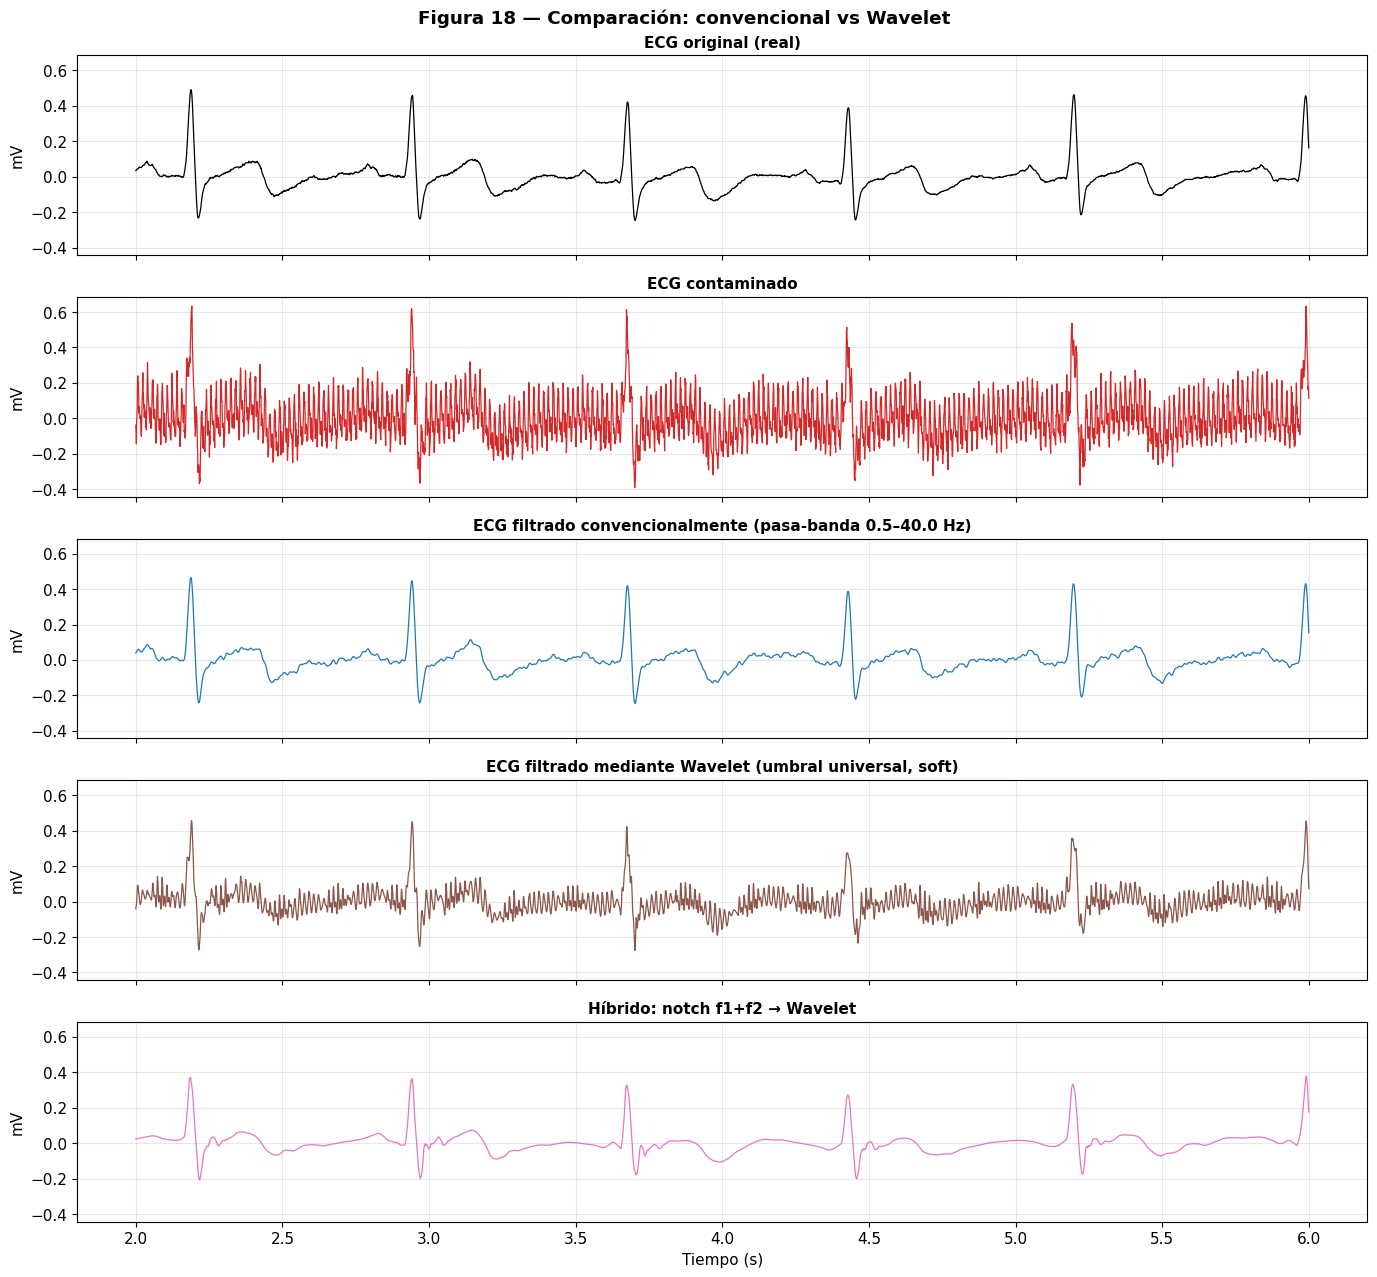

,RMSE (mV),SNR (dB),Correlación r
Contaminado (sin filtrar),0.1004,1.5343,0.7656
A — Pasa-banda,0.0344,10.8465,0.9591
B1 — Notch 60 Hz,0.0595,6.0810,0.8952
B2 — Notch 60+120 Hz,0.0341,10.8992,0.9615
LMS adaptativo,0.0348,10.7294,0.9608
Wavelet (denoising),0.0470,8.1196,0.9206
Híbrido notch + Wavelet,0.0257,13.3575,0.9799


In [ ]:
def denoising_wavelet(x, wavelet=WAVELET, nivel=NIVEL, modo="soft"):
    coefs = pywt.wavedec(x, wavelet, level=nivel)
    sigma = np.median(np.abs(coefs[-1])) / 0.6745            # ruido estimado a partir de D1
    umbral = sigma * np.sqrt(2 * np.log(len(x)))              # umbral universal
    coefs_umbral = [coefs[0]] + [pywt.threshold(c, umbral, mode=modo) for c in coefs[1:]]
    x_limpia = pywt.waverec(coefs_umbral, wavelet)[:len(x)]
    return x_limpia, umbral

# 1) Wavelet aplicada directamente a la señal contaminada
ecg_wavelet, umbral = denoising_wavelet(ecg_contaminado)
# 2) Enfoque híbrido: primero notch (quita interferencias), luego wavelet (quita ruido gaussiano)
ecg_hibrido, _ = denoising_wavelet(ecg_notch_f1f2)

print(f"Umbral universal aplicado: {umbral:.4f}")

comparar_senales([
    ("ECG original (real)", ecg_original, "black"),
    ("ECG contaminado", ecg_contaminado, "tab:red"),
    (f"ECG filtrado convencionalmente (pasa-banda {fc_baja}–{fc_alta} Hz)", ecg_pasabanda, "tab:blue"),
    ("ECG filtrado mediante Wavelet (umbral universal, soft)", ecg_wavelet, "tab:brown"),
    ("Híbrido: notch f1+f2 → Wavelet", ecg_hibrido, "tab:pink"),
], "Figura 18 — Comparación: convencional vs Wavelet")

resultados["Wavelet (denoising)"] = calcular_metricas(ecg_original, ecg_wavelet)
resultados["Híbrido notch + Wavelet"] = calcular_metricas(ecg_original, ecg_hibrido)
pd.DataFrame(resultados).T.round(4)

### 🔎 Interpretación — *Denoising* Wavelet
- La umbralización **reduce eficazmente el ruido gaussiano** (banda ancha, coeficientes pequeños) y tiende a **conservar los QRS**, porque sus coeficientes son grandes.
- Sin embargo, las **interferencias sinusoidales intensas** generan coeficientes grandes en D3–D4 que **superan el umbral** → pueden sobrevivir al *denoising*. La Wavelet no es la herramienta ideal para una interferencia de banda estrecha.
- El enfoque **híbrido** combina fortalezas: el notch quita las interferencias y la Wavelet el ruido de banda ancha.
- **Posibles distorsiones:** el *soft thresholding* reduce ligeramente la amplitud de los picos y puede generar pequeñas oscilaciones cerca de los QRS.

### ❓ Pregunta al estudiante
Cambia `modo="soft"` por `modo="hard"` y prueba la wavelet `"sym8"` en lugar de `"db4"`. ¿Cómo cambian la forma del QRS y las métricas?

✍️ **Respuesta:**

---
# 🟦 BLOQUE 6 — Comparación e interpretación *(10 min)* · 🔁 Retroalimentación

> A partir de aquí **no se introducen conceptos nuevos**: revisamos, comparamos y discutimos.

,RMSE (mV),SNR (dB),Correlación r,Mejora SNR vs contaminado (dB)
B2 — Notch 60+120 Hz,0.0341,10.8992,0.9615,9.3649
A — Pasa-banda,0.0344,10.8465,0.9591,9.3122
LMS adaptativo,0.0348,10.7294,0.9608,9.1951
B1 — Notch 60 Hz,0.0595,6.0810,0.8952,4.5468
Contaminado (sin filtrar),0.1004,1.5343,0.7656,0.0000


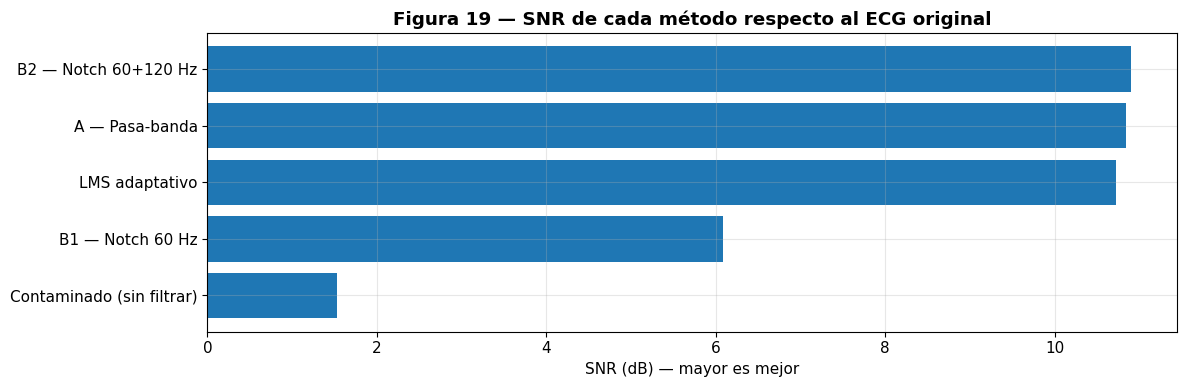

In [ ]:
tabla_final = pd.DataFrame(resultados).T
tabla_final["Mejora SNR vs contaminado (dB)"] = tabla_final["SNR (dB)"] - tabla_final.loc["Contaminado (sin filtrar)", "SNR (dB)"]
display(tabla_final.round(4).sort_values("SNR (dB)", ascending=False))

# Gráfico de barras de SNR
plt.figure(figsize=(12, 4))
orden = tabla_final.sort_values("SNR (dB)")
plt.barh(orden.index, orden["SNR (dB)"], color="tab:blue")
plt.xlabel("SNR (dB) — mayor es mejor")
plt.title("Figura 19 — SNR de cada método respecto al ECG original")
plt.tight_layout(); plt.show()

### Comparación cualitativa (complétala con tus observaciones)

| Criterio | Pasa-banda | Notch | LMS adaptativo | Wavelet | Híbrido |
|---|---|---|---|---|---|
| Reducción de interferencias | ✍️ | ✍️ | ✍️ | ✍️ | ✍️ |
| Reducción de ruido gaussiano | ✍️ | ✍️ | ✍️ | ✍️ | ✍️ |
| Conservación de la morfología | ✍️ | ✍️ | ✍️ | ✍️ | ✍️ |
| Distorsión introducida | ✍️ | ✍️ | ✍️ | ✍️ | ✍️ |
| Complejidad | Baja | Baja | Media | Media | Media |
| ¿Qué necesita conocer? | Banda del ECG | Frecuencia exacta | Señal de referencia | Wavelet, niveles, umbral | Ambos |

> ⚖️ **Ningún método es universalmente superior.** La elección depende del tipo de contaminación, de qué información fisiológica debe conservarse y de la aplicación (monitoreo, diagnóstico, detección de QRS, tiempo real…).

---
# 🟦 BLOQUE 7 — Retroalimentación, síntesis e infografía *(15 min)*

## 📝 Actividad de análisis

Responde de forma breve y justificada (2 – 4 líneas por pregunta).

**Pregunta 1.** ¿Por qué es importante conocer la frecuencia de muestreo de una señal biomédica?

✍️ **Respuesta:**

**Pregunta 2.** ¿Qué diferencia existe entre ruido e interferencia?

✍️ **Respuesta:**

**Pregunta 3.** ¿Por qué una interferencia sinusoidal puede observarse como un pico en el dominio de la frecuencia?

✍️ **Respuesta:**

**Pregunta 4.** ¿Qué sucede cuando aplicamos un filtro demasiado agresivo a una señal ECG? *(Sugerencia: prueba `fc_alta = 15` en el Experimento A y observa el QRS.)*

✍️ **Respuesta:**

**Pregunta 5.** ¿Cuál es la principal diferencia conceptual entre un filtro convencional y un filtro adaptativo?

✍️ **Respuesta:**

**Pregunta 6.** ¿Para qué sirve la Transformada Wavelet?

✍️ **Respuesta:**

**Pregunta 7.** ¿Por qué la Transformada Wavelet puede resultar útil para analizar señales biomédicas?

✍️ **Respuesta:**

**Pregunta 8.** ¿Qué información podría perderse durante el proceso de filtrado?

✍️ **Respuesta:**

**Pregunta 9.** Si conoces la frecuencia exacta de una interferencia, ¿qué tipo de filtro podrías utilizar?

✍️ **Respuesta:**

**Pregunta 10.** ¿Por qué no debemos evaluar un filtro únicamente observando visualmente la señal?

✍️ **Respuesta:**

## 🧠 SUMARIZE — ¿Qué aprendimos?

Resume en pocas líneas:

```text
1. ¿Qué problema tenía la señal?
2. ¿Cómo contaminamos la señal?
3. ¿Qué filtro utilizamos?
4. ¿Qué resultado obtuvimos?
5. ¿Para qué sirve un filtro adaptativo?
6. ¿Para qué sirve Wavelet?
7. ¿Qué método utilizarías y por qué?
```

✍️ **Respuesta:**

1.
2.
3.
4.
5.
6.
7.

## 🎨 Actividad final — Infografía científica

Elabora una infografía sencilla (Canva, PowerPoint, Google Slides o a mano y fotografiada) con estas secciones:

1. **Señal original** — ECG adquirido con BITalino/OpenSignals (Fs, duración, canal A2).
2. **Contaminación** — `ECG + interferencia 1 + interferencia 2 + ruido` (indica frecuencias y amplitudes usadas).
3. **Filtrado** — método(s) aplicado(s) y sus parámetros.
4. **Resultado** — comparación *Original / Contaminada / Filtrada* + una métrica (SNR o r).
5. **Conceptos clave** — una línea para cada uno: *Ruido, Interferencia, Filtro, Filtro adaptativo, Wavelet, Denoising*.
6. **Conclusión** — 3 a 5 líneas: ¿qué método recuperó mejor la señal y qué limitaciones observaste?

**Flujo que debe mostrar la infografía:**

```text
ECG REAL → CONTAMINACIÓN → ANÁLISIS → FILTRADO → FILTRO ADAPTATIVO → WAVELET → COMPARACIÓN → CONCLUSIONES
```

La siguiente celda genera una **figura base** con tus propios resultados que puedes insertar en la infografía.

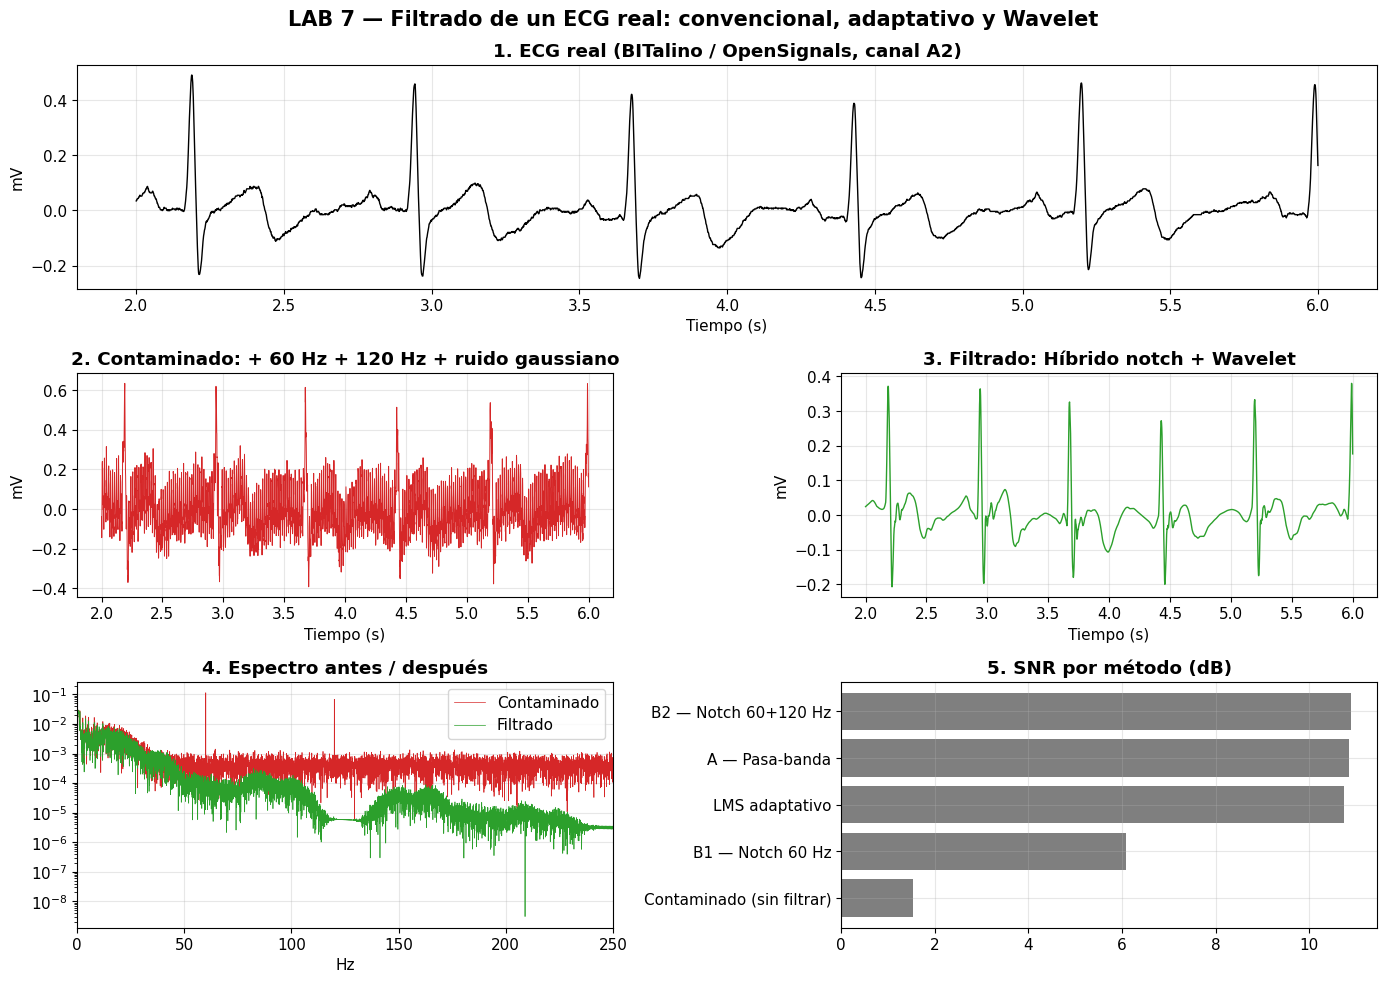

Figura guardada como 'figura_base_infografia.png'


In [ ]:
# Elige el método que consideres mejor para la infografía (cambia la clave si lo deseas)
METODO_ELEGIDO = "Híbrido notch + Wavelet"
senales_metodos = {
    "A — Pasa-banda": ecg_pasabanda,
    f"B2 — Notch {f1}+{f2} Hz": ecg_notch_f1f2,
    "LMS adaptativo": ecg_lms,
    "Wavelet (denoising)": ecg_wavelet,
    "Híbrido notch + Wavelet": ecg_hibrido,
}
ecg_elegido = senales_metodos[METODO_ELEGIDO]

fig = plt.figure(figsize=(14, 10))
grid = fig.add_gridspec(3, 2, height_ratios=[1, 1, 1.1])

ax1 = fig.add_subplot(grid[0, :])
ax1.plot(t[zoom], ecg_original[zoom], color="black", lw=1)
ax1.set_title("1. ECG real (BITalino / OpenSignals, canal A2)")

ax2 = fig.add_subplot(grid[1, 0])
ax2.plot(t[zoom], ecg_contaminado[zoom], color="tab:red", lw=0.7)
ax2.set_title(f"2. Contaminado: + {f1} Hz + {f2} Hz + ruido gaussiano")

ax3 = fig.add_subplot(grid[1, 1])
ax3.plot(t[zoom], ecg_elegido[zoom], color="tab:green", lw=1)
ax3.set_title(f"3. Filtrado: {METODO_ELEGIDO}")

ax4 = fig.add_subplot(grid[2, 0])
ax4.semilogy(freq, amp_contaminado, color="tab:red", lw=0.5, label="Contaminado")
fr_e, am_e = espectro_amplitud(ecg_elegido, Fs)
ax4.semilogy(fr_e, am_e, color="tab:green", lw=0.5, label="Filtrado")
ax4.set_xlim(0, F_MAX_GRAFICO); ax4.legend(); ax4.set_xlabel("Hz")
ax4.set_title("4. Espectro antes / después")

ax5 = fig.add_subplot(grid[2, 1])
orden = tabla_final.sort_values("SNR (dB)")
colores = ["tab:green" if nombre == METODO_ELEGIDO else "tab:gray" for nombre in orden.index]
ax5.barh(orden.index, orden["SNR (dB)"], color=colores)
ax5.set_title("5. SNR por método (dB)")

for eje in (ax1, ax2, ax3):
    eje.set_xlabel("Tiempo (s)"); eje.set_ylabel("mV")
fig.suptitle("LAB 7 — Filtrado de un ECG real: convencional, adaptativo y Wavelet", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("figura_base_infografia.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figura guardada como 'figura_base_infografia.png'")

## 🔁 Guía de retroalimentación para el docente (últimos 30 min)

| Momento | Actividad |
|---|---|
| min 90 – 95 | Cierre de la discusión Wavelet: ¿por qué sobrevivieron las interferencias al umbral? |
| min 95 – 105 | Revisar la tabla final y la Figura 19: comparar filtros; contrastar métricas con lo visual. |
| min 105 – 112 | Discutir errores frecuentes y revisar respuestas a las preguntas 1 – 10. |
| min 112 – 120 | Revisar avance de la síntesis e infografía; responder preguntas. |

**Errores frecuentes a discutir:**
- Graficar `nSeq` o las columnas digitales como si fueran ECG.
- Usar `nSeq` como eje de tiempo.
- Confundir ruido (aleatorio, banda ancha) con interferencia (estructurada, banda estrecha).
- Elegir un pasa-bajas con corte muy bajo y "aplanar" el QRS.
- Interpretar que una SNR alta garantiza una morfología clínicamente correcta.
- Olvidar que el LMS necesita un tiempo de convergencia.
- Asumir que la Wavelet elimina cualquier tipo de contaminación.

**Ideas clave para el cierre:**
- Filtro **convencional**: coeficientes fijos, efectivo si conocemos la banda del ruido.
- Filtro **adaptativo**: coeficientes que cambian, requiere una referencia, sigue interferencias variables.
- **Wavelet**: análisis tiempo-escala, útil para eventos localizados (QRS) y ruido de banda ancha.
- En la práctica se **combinan** técnicas según el problema.

## ✅ Conclusiones del laboratorio

✍️ Escribe tus conclusiones (5 – 8 líneas), considerando: reducción del ruido, conservación de la morfología, distorsión, complejidad y aplicación biomédica.

✍️ **Conclusiones:**

---
# 📦 ENTREGA

### 1. Jupyter Notebook (`.ipynb`)
Debe contener:
- código ejecutado sin errores;
- todos los gráficos generados;
- respuestas a las preguntas de cada bloque y a las 10 preguntas de análisis;
- interpretación de resultados;
- sección *SUMARIZE* y conclusiones.

### 2. Infografía (PDF o PNG)
Debe sintetizar el flujo completo:

```text
ECG REAL
   ↓
CONTAMINACIÓN
   ↓
ANÁLISIS
   ↓
FILTRADO
   ↓
FILTRO ADAPTATIVO
   ↓
WAVELET
   ↓
COMPARACIÓN
   ↓
CONCLUSIONES
```

**Nombre de archivos sugerido:** `LAB7_Apellido_Nombre.ipynb` y `LAB7_Apellido_Nombre_infografia.pdf`

# 📊 Criterios de evaluación

| Criterio | Peso | Logrado (100%) | En proceso (50%) | No logrado (0%) |
|---|---:|---|---|---|
| Carga y comprensión de datos | 15% | Lee cabecera, identifica A2, construye `t` correctamente y justifica no usar `nSeq`. | Carga los datos con errores menores de interpretación. | No identifica el canal ECG o usa un eje temporal incorrecto. |
| Contaminación artificial | 15% | Genera y visualiza ambas interferencias y el ruido; interpreta el espectro. | Genera la contaminación pero la interpretación es incompleta. | No genera la contaminación o no la analiza. |
| Aplicación de filtros | 20% | Aplica pasa-banda y notch, muestra respuestas en frecuencia y explica efectos. | Aplica los filtros sin justificar parámetros. | No aplica los filtros correctamente. |
| Análisis e interpretación | 20% | Integra métricas y observación visual; reconoce distorsiones y limitaciones. | Interpretación superficial o solo visual. | Sin interpretación. |
| Filtro adaptativo y Wavelet | 15% | Explica el LMS (referencia, error, coeficientes) y el denoising Wavelet; experimenta con parámetros. | Ejecuta el código sin explicar los conceptos. | No aborda estos métodos. |
| Infografía y comunicación | 15% | Infografía clara, completa (6 secciones) y con conclusión fundamentada. | Infografía incompleta o poco clara. | No entrega infografía. |
| **Total** | **100%** | | | |